# Master Notebook: Embedding Boosting Ensemble - Turkish NLI Models Comparison
## Unified Framework for Multiple Turkish Sentence Embedders

This master notebook compares Turkish sentence embedding models optimized for NLI:
- **emrecan/bert-base-turkish-cased-mean-nli-stsb-tr** (768-dim, STS-optimized Turkish)
- **dbmdz/bert-base-turkish-cased** (768-dim, Turkish-specific)
- **trmteb/turkish-embedding-model** (768-dim, cache prefix: `tr_embedding`)
- **trmteb/turkish-embedding-model-fine-tuned** (768-dim, cache prefix: `tr_embedding_ft`)
- **magibu/embeddingmagibu-152m** (768-dim, cache prefix: `magibu_152m`)
- **newmindai/TurkEmbed4Retrieval-Static** (768-dim, cache prefix: `turk_embed_static`)

Key Features:
- Turkish & Multilingual (can be added) language support
- Uses cached embeddings (npz/npy files) for all splits (train/validation/test)
- Generates embeddings on-the-fly if cache not available
- Uses full dataset for training (no subsampling)
- Compares XGBoost vs LightGBM across all models
- Generates comprehensive visualizations and metrics


In [52]:
!pip install sentence-transformers datasets xgboost lightgbm

## Section 1: Setup and Configuration


In [53]:
import os, sys, json, numpy as np, pandas as pd, warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Configuration
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# MODEL SELECTION - Change this to switch between models
# TURKISH/MULTILINGUAL EMBEDDERS (Optimized for Turkish NLI):
# 'emrecan/bert-base-turkish-cased-mean-nli-stsb-tr' (768-dim, STS Task-optimized Turkish)
# 'dbmdz/bert-base-turkish-cased' (768-dim, Turkish-specific)
# 'trmteb/turkish-embedding-model' (768-dim, cache prefix: tr_embedding)
# 'trmteb/turkish-embedding-model-fine-tuned' (768-dim, cache prefix: tr_embedding_ft)
# 'magibu/embeddingmagibu-152m' (cache prefix: magibu_152m)
# 'newmindai/TurkEmbed4Retrieval-Static' (cache prefix: turk_embed_static)


EMBEDDING_MODEL_NAME = 'magibu/embeddingmagibu-152m'  # ← Recommended for Turkish NLI

# Model configurations (Turkish/Multilingual Only)
# NOTE: cache_prefix must match actual cache file names in train_cache/, test_cache/, validation_cache/
# Existing cache files: tr_bert_base_*, tr_bert_nli_*, tr_embedding_*, tr_embedding_ft_*
MODEL_CONFIGS = {
    'emrecan/bert-base-turkish-cased-mean-nli-stsb-tr': {
        'dim': 768,
        'name_short': 'stsb_tr_emrecan',
        'cache_prefix': 'tr_bert_nli',
        'desc': 'STS-optimized Turkish (768-dim)'
    },
    'dbmdz/bert-base-turkish-cased': {
        'dim': 768,
        'name_short': 'turkbert',
        'cache_prefix': 'tr_bert_base',
        'desc': 'Turkish-specific (768-dim)'
    },
    'trmteb/turkish-embedding-model': {
        'dim': 768,
        'name_short': 'tr_embedding',
        'cache_prefix': 'tr_embedding',
        'desc': 'Turkish embedding model (768-dim)'
    },
    'trmteb/turkish-embedding-model-fine-tuned': {
        'dim': 768,
        'name_short': 'tr_embedding_ft',
        'cache_prefix': 'tr_embedding_ft',
        'desc': 'Fine-tuned Turkish embedding model (768-dim)'
    },
    'magibu/embeddingmagibu-152m': {
        'dim': 768,
        'name_short': 'magibu_152m',
        'cache_prefix': 'magibu_152m',
        'desc': 'Magibu Embedding Model 152M'
    },
    'newmindai/TurkEmbed4Retrieval-Static': {
        'dim': 768,
        'name_short': 'turk_embed_static',
        'cache_prefix': 'turk_embed_static',
        'desc': 'TurkEmbed4Retrieval Static'
    }
}

model_config = MODEL_CONFIGS[EMBEDDING_MODEL_NAME]
EMBEDDING_DIM = model_config['dim']
CACHE_PREFIX = model_config['cache_prefix']

# Paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'ensemble' else Path.cwd()
TRAIN_CACHE_DIR = PROJECT_ROOT / 'train_cache'
VALIDATION_CACHE_DIR = PROJECT_ROOT / 'validation_cache'
TEST_CACHE_DIR = PROJECT_ROOT / 'test_cache'
CACHE_DIRS = {
    'train': TRAIN_CACHE_DIR,
    'validation': VALIDATION_CACHE_DIR,
    'test': TEST_CACHE_DIR
}
CACHE_DIR = TRAIN_CACHE_DIR
OUTPUT_DIR = PROJECT_ROOT / f'results_embedding_{model_config["name_short"]}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\n✅ Configuration loaded')
print(f'  Model: {EMBEDDING_MODEL_NAME}')
print(f'  Dimension: {EMBEDDING_DIM}')
print(f'  Output directory: {OUTPUT_DIR}')
print(f'  Train cache directory: {CACHE_DIR}')
print(f'  Validation cache directory: {VALIDATION_CACHE_DIR}')
print(f'  Test cache directory: {TEST_CACHE_DIR}')

# Datasets Configuration
DATASETS_CONFIG = {
    'snli_tr_1_1': {
        'repo': 'yilmazzey/sdp2-nli',
        'config': 'snli_tr_1_1',
        'splits': ['train', 'validation', 'test']
    },
    'multinli_tr_1_1': {
        'repo': 'yilmazzey/sdp2-nli',
        'config': 'multinli_tr_1_1',
        'splits': ['train', 'validation_matched', 'validation_mismatched']
    },
    'trglue_mnli': {
        'repo': 'yilmazzey/sdp2-nli',
        'config': 'trglue_mnli',
        'splits': ['train', 'validation_matched', 'validation_mismatched', 'test_matched', 'test_mismatched']
    }
}

LABEL_NAMES = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}
LABEL_TO_ID = {v: k for k, v in LABEL_NAMES.items()}

# Boosting Configuration
BOOSTING_PARAMS = {
    'xgboost': {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': SEED, 'tree_method': 'auto', 'objective': 'multi:softmax', 'num_class': 3, 'verbosity': 0},
    'lightgbm': {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': SEED, 'verbose': -1, 'num_class': 3, 'objective': 'multiclass'}
}


Using device: cuda

✅ Configuration loaded
  Model: magibu/embeddingmagibu-152m
  Dimension: 768
  Output directory: /content/results_embedding_magibu_152m
  Train cache directory: /content/train_cache
  Validation cache directory: /content/validation_cache
  Test cache directory: /content/test_cache


## Section 2: Load or Generate Embedding Model


In [54]:
print(f'\nLoading embedding model: {EMBEDDING_MODEL_NAME}...')
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)
print(f'✅ Model loaded successfully')



Loading embedding model: magibu/embeddingmagibu-152m...


modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/986 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

✅ Model loaded successfully


## Section 3: Embedding Management Functions


In [55]:
def load_cached_embeddings(dataset_name: str, split: str = 'train') -> Optional[Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Load cached embeddings from npz/npy files based on split type and model prefix."""
    # Determine cache directory based on split
    if split == 'train':
        split_cache_dir = CACHE_DIRS['train']
    elif split in ['validation', 'validation_matched', 'validation_mismatched']:
        split_cache_dir = CACHE_DIRS['validation']
    elif split in ['test', 'test_matched', 'test_mismatched']:
        split_cache_dir = CACHE_DIRS['test']
    else:
        return None

    if not split_cache_dir.exists():
        return None

    # Search for cache files using model-specific prefix and dataset patterns
    # Pattern: {CACHE_PREFIX}_{dataset_name}_{split}.npz
    npz_pattern = f'{CACHE_PREFIX}_{dataset_name}_{split}.npz'
    npy_pattern = f'{CACHE_PREFIX}_{dataset_name}_{split}_labels.npy'

    cache_file = split_cache_dir / npz_pattern
    labels_file = split_cache_dir / npy_pattern

    if cache_file.exists() and labels_file.exists():
        try:
            data = np.load(cache_file)
            p_emb = data['premise_embeddings']
            h_emb = data['hypothesis_embeddings']
            labels = np.load(labels_file)
            print(f'  ✅ Loaded cached {split} embeddings from {split_cache_dir.name}/ (prefix: {CACHE_PREFIX})')
            return p_emb, h_emb, labels
        except Exception as e:
            print(f'  ⚠️ Error loading cache: {e}')
            return None
    else:
        # Fallback: try flexible pattern matching if exact prefix match fails
        npz_pattern_flex = f'{CACHE_PREFIX}*{dataset_name}*{split}.npz'
        npy_pattern_flex = f'{CACHE_PREFIX}*{dataset_name}*{split}_labels.npy'
        npz_files = list(split_cache_dir.glob(npz_pattern_flex))
        npy_files = list(split_cache_dir.glob(npy_pattern_flex))

        if npz_files and npy_files:
            print(f'  ℹ️ Exact prefix match not found, using flexible pattern matching')
            cache_file = npz_files[0]
            labels_file = npy_files[0]
            try:
                data = np.load(cache_file)
                p_emb = data['premise_embeddings']
                h_emb = data['hypothesis_embeddings']
                labels = np.load(labels_file)
                print(f'  ✅ Loaded cached {split} embeddings (fallback: {cache_file.name})')
                return p_emb, h_emb, labels
            except Exception as e:
                print(f'  ⚠️ Error loading cache: {e}')
                return None

    return None

def load_dataset_split(dataset_name: str, split: str) -> Tuple[List[str], List[str], np.ndarray]:
    """Load dataset split from Hugging Face."""
    config = DATASETS_CONFIG[dataset_name]
    dataset = load_dataset(config['repo'], config['config'], split=split)
    premises = dataset['premise']
    hypotheses = dataset['hypothesis']
    labels = np.array(dataset['label'])
    return premises, hypotheses, labels

def generate_embeddings(premises: List[str], hypotheses: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Generate embeddings for given texts."""
    print(f'  Encoding {len(premises)} pairs...')
    p_emb = embedding_model.encode(premises, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    h_emb = embedding_model.encode(hypotheses, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    return p_emb, h_emb

def get_embeddings(dataset_name: str, split: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Get embeddings - from cache if available, else generate."""
    print(f'  Getting {split} embeddings for {dataset_name}...')

    # Try cache first
    cached = load_cached_embeddings(dataset_name, split)
    if cached is not None:
        return cached

    # Generate if not cached
    premises, hypotheses, labels = load_dataset_split(dataset_name, split)
    p_emb, h_emb = generate_embeddings(premises, hypotheses)
    print(f'  ✅ Generated {split} embeddings')
    return p_emb, h_emb, labels

def engineer_features(p_emb: np.ndarray, h_emb: np.ndarray) -> np.ndarray:
    """Engineer features from embedding pairs with safe numerical handling."""
    n_samples = len(p_emb)

    # Cosine similarity with safe division
    p_norm_safe = np.linalg.norm(p_emb, axis=1) + 1e-8
    h_norm_safe = np.linalg.norm(h_emb, axis=1) + 1e-8
    cosine_sim = np.sum(p_emb * h_emb, axis=1) / (p_norm_safe * h_norm_safe)

    # L2 distance
    l2_dist = np.linalg.norm(p_emb - h_emb, axis=1)

    # Norm difference and ratio with safe division
    p_norm = np.linalg.norm(p_emb, axis=1)
    h_norm = np.linalg.norm(h_emb, axis=1)
    norm_diff = p_norm - h_norm
    norm_ratio = p_norm / (h_norm + 1e-8)

    # Element-wise operations
    elem_diff = p_emb - h_emb
    elem_mean = (p_emb + h_emb) / 2
    elem_product = p_emb * h_emb

    # Combine all features
    features = np.concatenate([
        p_emb, h_emb,
        cosine_sim.reshape(-1, 1),
        l2_dist.reshape(-1, 1),
        norm_diff.reshape(-1, 1),
        norm_ratio.reshape(-1, 1),
        elem_diff, elem_mean, elem_product
    ], axis=1)

    # Replace any inf or nan with 0
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

    return features

print('✅ Helper functions defined')


✅ Helper functions defined


## Section 4: XGBoost Training and Evaluation


In [56]:
print(f'\n{"="*70}\nXGBOOST TRAINING\n{"="*70}')
xgboost_results = {}

for dataset_name, config in DATASETS_CONFIG.items():
    print(f'\nDataset: {dataset_name}')
    dataset_results = {}

    for split in config['splits']:
        print(f'  Split: {split}')
        p_emb, h_emb, y = get_embeddings(dataset_name, split)

        # Engineer features
        X = engineer_features(p_emb, h_emb)

        # Check for inf/nan before scaling
        if np.isinf(X).any() or np.isnan(X).any():
            print(f'    ⚠️ Warning: Found inf/nan in features, cleaning...')
            X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

        print(f'    Features: {X.shape}')
        print(f'    Feature range: [{X.min():.2f}, {X.max():.2f}]')

        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Final check for inf/nan after scaling
        if np.isinf(X_scaled).any() or np.isnan(X_scaled).any():
            print(f'    ⚠️ Warning: inf/nan after scaling, cleaning...')
            X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
        )

        print(f'  Training XGBoost...')

        # XGBoost with explicit missing value handling
        model = xgb.XGBClassifier(
            **BOOSTING_PARAMS['xgboost'],
            missing=np.nan  # Explicitly handle missing values
        )
        model.fit(X_train, y_train, verbose=False)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)  # Get confidence scores

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')

        dataset_results[split] = {
            'accuracy': float(acc), 'f1_macro': float(f1),
            'precision_macro': float(precision), 'recall_macro': float(recall),
            'n_samples': len(X), 'n_features': X.shape[1],
            'original_samples': len(p_emb) if split == 'train' else len(X),
            'model': model,  # Store model for feature importance
            'y_test': y_test,
            'y_pred': y_pred,
            'y_proba': y_proba  # Store confidence scores
        }
        print(f'    ✅ Acc: {acc:.4f} | F1: {f1:.4f}')

        cm = confusion_matrix(y_test, y_pred)
        cm_path = OUTPUT_DIR / f'xgboost_confusion_{dataset_name}_{split}.csv'
        np.savetxt(cm_path, cm, fmt='%d', delimiter=',',
                   header=','.join([LABEL_NAMES[i] for i in range(3)]), comments='')

        # Memory cleanup
        del X, X_scaled, X_train, X_test, model
        import gc
        gc.collect()

    xgboost_results[dataset_name] = dataset_results

print(f'\n✅ XGBoost completed')



XGBOOST TRAINING

Dataset: snli_tr_1_1
  Split: train
  Getting train embeddings for snli_tr_1_1...
  ✅ Loaded cached train embeddings from train_cache/ (prefix: magibu_152m)
    Features: (548487, 3844)
    Feature range: [-0.19, 1.29]
  Training XGBoost...
    ✅ Acc: 0.3464 | F1: 0.2005
  Split: validation
  Getting validation embeddings for snli_tr_1_1...
  ✅ Loaded cached validation embeddings from validation_cache/ (prefix: magibu_152m)
    Features: (9836, 3844)
    Feature range: [-0.24, 1.30]
  Training XGBoost...
    ✅ Acc: 0.6001 | F1: 0.5952
  Split: test
  Getting test embeddings for snli_tr_1_1...
  ✅ Loaded cached test embeddings from test_cache/ (prefix: magibu_152m)
    Features: (9824, 3844)
    Feature range: [-0.19, 1.28]
  Training XGBoost...
    ✅ Acc: 0.5964 | F1: 0.5932

Dataset: multinli_tr_1_1
  Split: train
  Getting train embeddings for multinli_tr_1_1...
  ✅ Loaded cached train embeddings from train_cache/ (prefix: magibu_152m)
    Features: (392599, 3844)


## Section 5: LightGBM Training and Evaluation


In [57]:
print(f'\n{"="*70}\nLIGHTGBM TRAINING\n{"="*70}')
lightgbm_results = {}


for dataset_name, config in DATASETS_CONFIG.items():
    print(f'\nDataset: {dataset_name}')
    dataset_results = {}

    for split in config['splits']:
        print(f'  Split: {split}')
        p_emb, h_emb, y = get_embeddings(dataset_name, split)
        X = engineer_features(p_emb, h_emb)

        Xs = StandardScaler().fit_transform(X)
        Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, random_state=SEED, stratify=y)

        print(f'  Training LightGBM...')
        m = lgb.LGBMClassifier(**BOOSTING_PARAMS['lightgbm'])
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        yp_proba = m.predict_proba(Xte)  # Get confidence scores

        acc = accuracy_score(yte, yp)
        f1 = f1_score(yte, yp, average='macro')
        prec = precision_score(yte, yp, average='macro')
        rec = recall_score(yte, yp, average='macro')

        dataset_results[split] = {
            'accuracy': float(acc), 'f1_macro': float(f1),
            'precision_macro': float(prec), 'recall_macro': float(rec),
            'n_samples': len(X), 'n_features': X.shape[1],
            'model': m,  # Store model for feature importance
            'y_test': yte,
            'y_pred': yp,
            'y_proba': yp_proba  # Store confidence scores
        }
        print(f'    ✅ Acc: {acc:.4f} | F1: {f1:.4f}')

        cm = confusion_matrix(yte, yp)
        cm_path = OUTPUT_DIR / f'lightgbm_confusion_{dataset_name}_{split}.csv'
        np.savetxt(cm_path, cm, fmt='%d', delimiter=',', header=','.join([LABEL_NAMES[i] for i in range(3)]), comments='')

    lightgbm_results[dataset_name] = dataset_results

print(f'\n✅ LightGBM completed')



LIGHTGBM TRAINING

Dataset: snli_tr_1_1
  Split: train
  Getting train embeddings for snli_tr_1_1...
  ✅ Loaded cached train embeddings from train_cache/ (prefix: magibu_152m)
  Training LightGBM...
    ✅ Acc: 0.3460 | F1: 0.2000
  Split: validation
  Getting validation embeddings for snli_tr_1_1...
  ✅ Loaded cached validation embeddings from validation_cache/ (prefix: magibu_152m)
  Training LightGBM...
    ✅ Acc: 0.6098 | F1: 0.6063
  Split: test
  Getting test embeddings for snli_tr_1_1...
  ✅ Loaded cached test embeddings from test_cache/ (prefix: magibu_152m)
  Training LightGBM...
    ✅ Acc: 0.6010 | F1: 0.5977

Dataset: multinli_tr_1_1
  Split: train
  Getting train embeddings for multinli_tr_1_1...
  ✅ Loaded cached train embeddings from train_cache/ (prefix: magibu_152m)
  Training LightGBM...
    ✅ Acc: 0.3334 | F1: 0.1699
  Split: validation_matched
  Getting validation_matched embeddings for multinli_tr_1_1...
  ✅ Loaded cached validation_matched embeddings from validatio

## Section 6: Save Results


In [58]:
# Clean results for JSON serialization (remove model objects and numpy arrays)
def clean_results_for_json(results_dict):
    """Remove non-serializable objects (models, arrays) from results"""
    cleaned = {}
    for dataset, splits in results_dict.items():
        cleaned[dataset] = {}
        for split, metrics in splits.items():
            cleaned[dataset][split] = {
                k: v for k, v in metrics.items()
                if k not in ['model', 'y_test', 'y_pred', 'y_proba']  # Remove non-serializable
            }
    return cleaned

results = {
    'method': 'Sentence Embedding + Boosting',
    'embedding_model': EMBEDDING_MODEL_NAME,
    'embedding_dim': EMBEDDING_DIM,
    'xgboost': clean_results_for_json(xgboost_results),
    'lightgbm': clean_results_for_json(lightgbm_results)
}

json_path = OUTPUT_DIR / f'embedding_{model_config["name_short"]}_results.json'
with open(json_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f'✅ Results saved to {json_path}')


✅ Results saved to /content/results_embedding_magibu_152m/embedding_magibu_152m_results.json


## Section 7: Results Summary (Evaluation Splits ?)

In [59]:
print(f'\n{"="*70}\nSUMMARY: {EMBEDDING_MODEL_NAME}\n{"="*70}\n')

all_results = []
for dataset_name in DATASETS_CONFIG.keys():
    for split in DATASETS_CONFIG[dataset_name]['splits']:
        xgb_acc = xgboost_results[dataset_name][split]['accuracy']
        lgb_acc = lightgbm_results[dataset_name][split]['accuracy']
        winner = 'XGB' if xgb_acc > lgb_acc else 'LGB'
        all_results.append({
            'Dataset': dataset_name,
            'Split': split,
            'XGBoost Acc': round(xgb_acc, 4),
            'LightGBM Acc': round(lgb_acc, 4),
            'Winner': winner,
            'Δ': round(abs(xgb_acc - lgb_acc), 4)
        })

# Display as clean table
df_summary = pd.DataFrame(all_results)
display(df_summary)


SUMMARY: magibu/embeddingmagibu-152m



,Dataset,Split,XGBoost Acc,LightGBM Acc,Winner,Δ
0,snli_tr_1_1,train,0.3464,0.3460,XGB,0.0004
1,snli_tr_1_1,validation,0.6001,0.6098,LGB,0.0097
2,snli_tr_1_1,test,0.5964,0.6010,LGB,0.0046
3,multinli_tr_1_1,train,0.3333,0.3334,LGB,0.0001
4,multinli_tr_1_1,validation_matched,0.4623,0.4801,LGB,0.0178
5,multinli_tr_1_1,validation_mismatched,0.4870,0.4814,XGB,0.0056
6,trglue_mnli,train,0.3379,0.3379,LGB,0.0000
7,trglue_mnli,validation_matched,0.6652,0.6713,LGB,0.0061
8,trglue_mnli,validation_mismatched,0.7130,0.7071,XGB,0.0060
9,trglue_mnli,test_matched,0.6570,0.6548,XGB,0.0022


## Section 8: Visualizations


✅ Visualization saved to /content/results_embedding_magibu_152m/embedding_magibu_152m_comparison.png


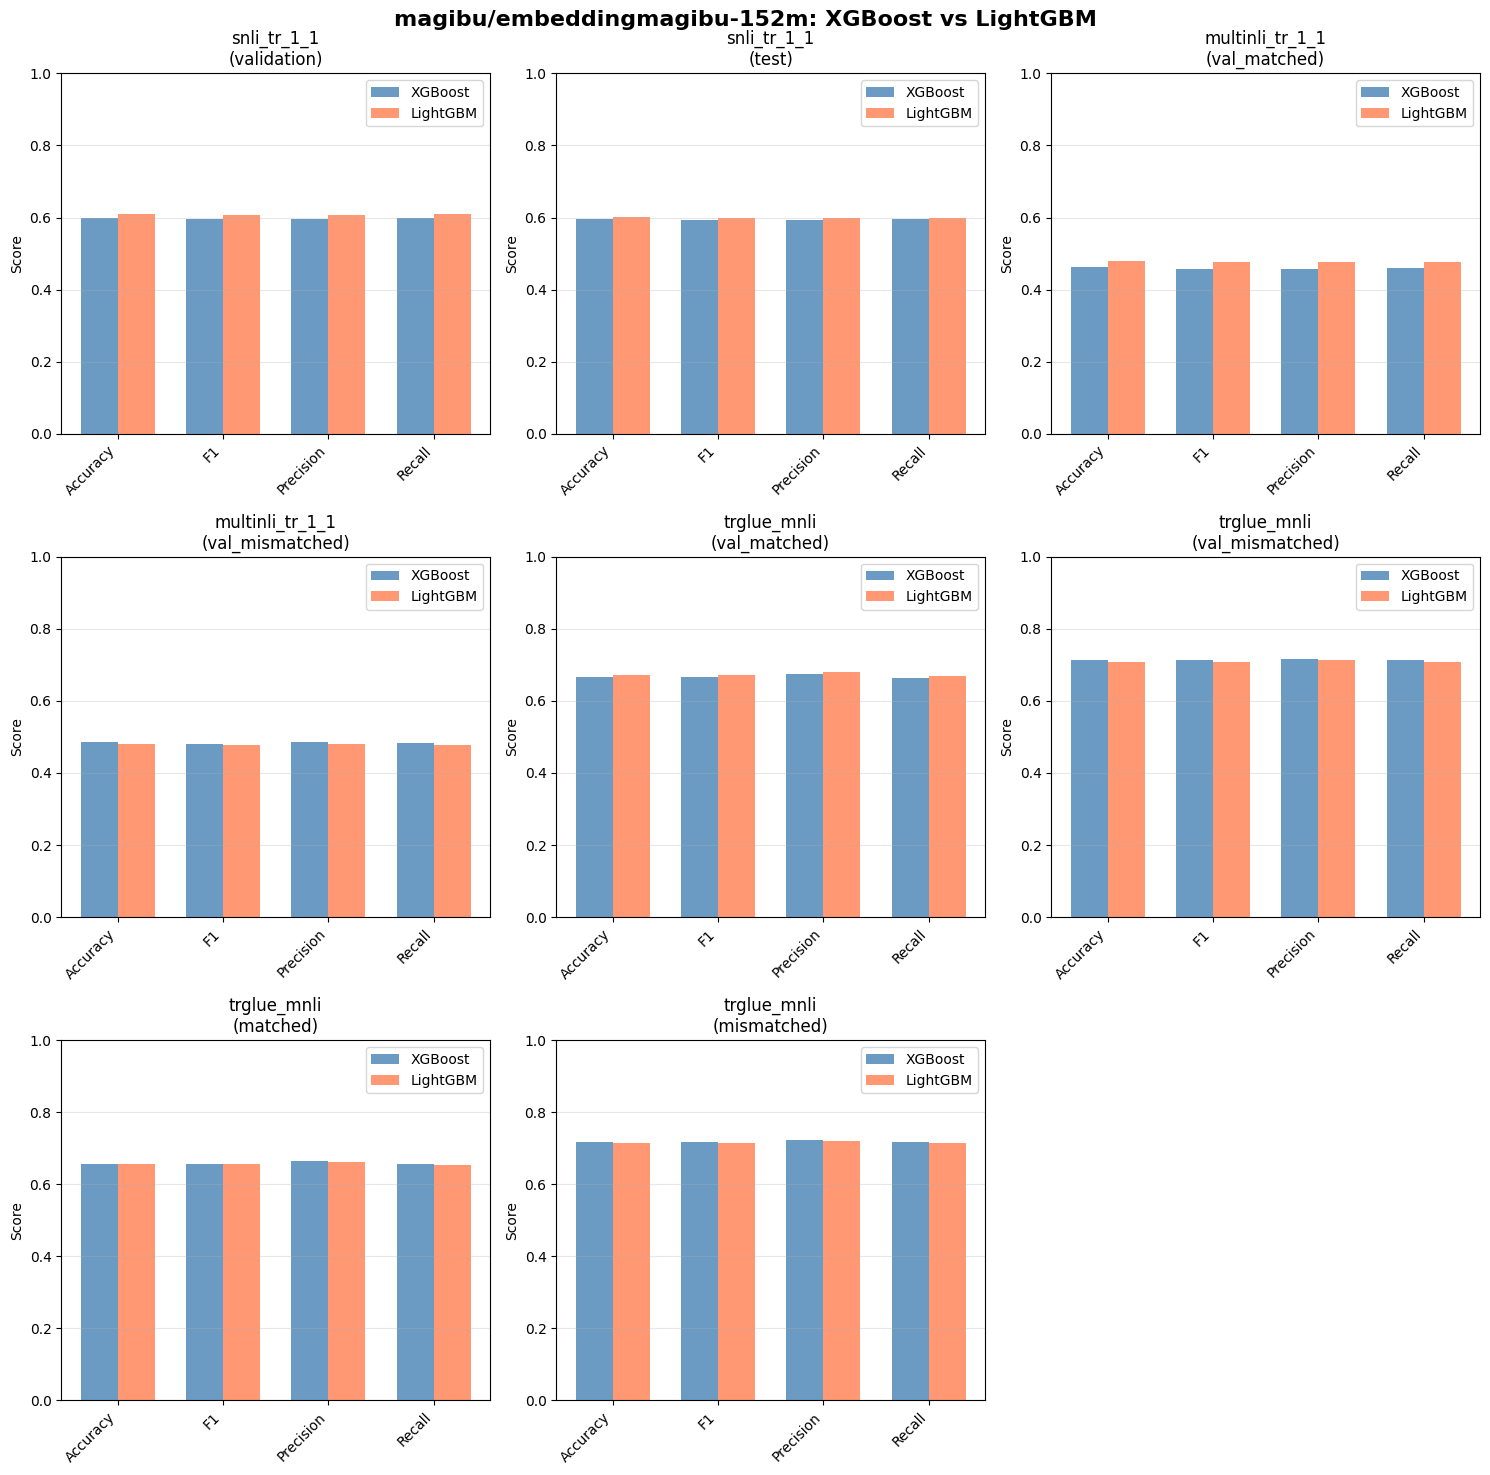

In [60]:
# Count only non-train splits
splits_to_plot = []
for dataset_name in DATASETS_CONFIG.keys():
    for split in DATASETS_CONFIG[dataset_name]['splits']:
        if split != 'train':
            splits_to_plot.append((dataset_name, split))

n_plots = len(splits_to_plot)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
fig.suptitle(f'{EMBEDDING_MODEL_NAME}: XGBoost vs LightGBM', fontsize=16, fontweight='bold')

# Flatten axes if needed
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, (dataset_name, split) in enumerate(splits_to_plot):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row, col]

    xgb_m = xgboost_results[dataset_name][split]
    lgb_m = lightgbm_results[dataset_name][split]

    names = ['Accuracy', 'F1', 'Precision', 'Recall']
    xgb_v = [xgb_m['accuracy'], xgb_m['f1_macro'], xgb_m['precision_macro'], xgb_m['recall_macro']]
    lgb_v = [lgb_m['accuracy'], lgb_m['f1_macro'], lgb_m['precision_macro'], lgb_m['recall_macro']]

    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, xgb_v, w, label='XGBoost', alpha=0.8, color='steelblue')
    ax.bar(x + w/2, lgb_v, w, label='LightGBM', alpha=0.8, color='coral')
    ax.set_ylabel('Score')

    display_split = split.replace('validation_', 'val_').replace('test_', '')
    ax.set_title(f'{dataset_name}\n({display_split})')

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(n_plots, n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
viz_path = OUTPUT_DIR / f'embedding_{model_config["name_short"]}_comparison.png'
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f'✅ Visualization saved to {viz_path}')
plt.show()


## Section 8.5: Dataset Difficulty Analysis

### Which Turkish NLI benchmark is most challenging?
This analysis ranks datasets by average performance across both boosters.
Lower accuracy = **harder dataset for Turkish NLI task**



DATASET DIFFICULTY RANKING

📊 RANKING (Hardest → Easiest):

1. multinli_tr_1_1      | Avg Acc: 0.4777 | 🔴 HARD
2. snli_tr_1_1          | Avg Acc: 0.6018 | 🟡 MEDIUM
3. trglue_mnli          | Avg Acc: 0.6875 | 🟢 EASY

✅ Dataset difficulty ranking saved to /content/results_embedding_magibu_152m/dataset_difficulty_ranking.png


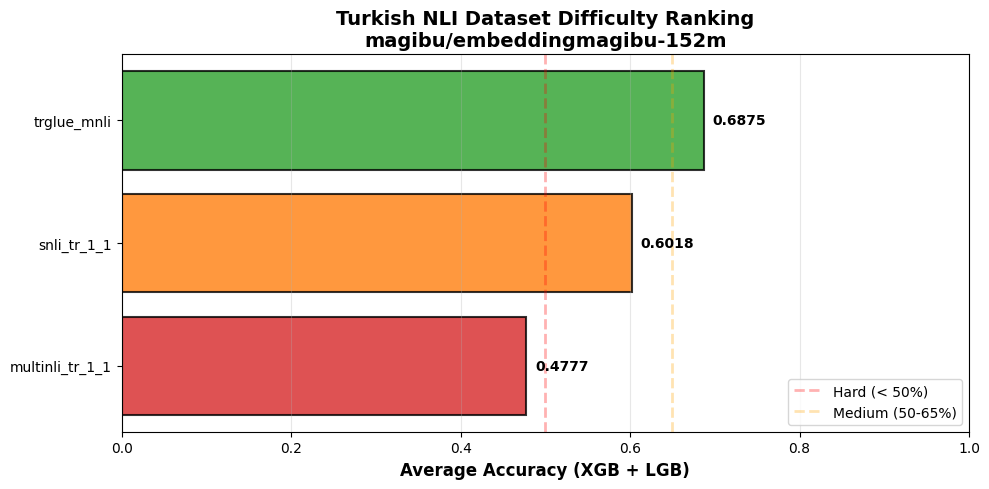

In [61]:
print("\n" + "="*70)
print("DATASET DIFFICULTY RANKING")
print("="*70 + "\n")

# Calculate average accuracy per dataset
dataset_performance = {}
for dataset_name in DATASETS_CONFIG.keys():
    accs = []
    for split in DATASETS_CONFIG[dataset_name]['splits']:
        if split == 'train':
            continue
        xgb_acc = xgboost_results[dataset_name][split]['accuracy']
        lgb_acc = lightgbm_results[dataset_name][split]['accuracy']
        accs.append((xgb_acc + lgb_acc) / 2)  # Average of both boosters

    avg_acc = np.mean(accs)
    dataset_performance[dataset_name] = {
        'avg_accuracy': avg_acc,
        'n_evals': len(accs),
        'scores': accs
    }

# Rank by difficulty (ascending accuracy = harder)
ranked_datasets = sorted(dataset_performance.items(),
                        key=lambda x: x[1]['avg_accuracy'])

print("📊 RANKING (Hardest → Easiest):\n")
for rank, (dataset, perf) in enumerate(ranked_datasets, 1):
    difficulty_level = "🔴 HARD" if perf['avg_accuracy'] < 0.50 else "🟡 MEDIUM" if perf['avg_accuracy'] < 0.65 else "🟢 EASY"
    print(f"{rank}. {dataset:20} | Avg Acc: {perf['avg_accuracy']:.4f} | {difficulty_level}")

# Visualization: Dataset Difficulty Bars
fig, ax = plt.subplots(figsize=(10, 5))

datasets_sorted = [d[0] for d in ranked_datasets]
accs_sorted = [d[1]['avg_accuracy'] for d in ranked_datasets]

colors = ['#d62728' if acc < 0.50 else '#ff7f0e' if acc < 0.65 else '#2ca02c'
          for acc in accs_sorted]

bars = ax.barh(datasets_sorted, accs_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (dataset, acc) in enumerate(zip(datasets_sorted, accs_sorted)):
    ax.text(acc + 0.01, i, f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Average Accuracy (XGB + LGB)', fontsize=12, fontweight='bold')
ax.set_title(f'Turkish NLI Dataset Difficulty Ranking\n{EMBEDDING_MODEL_NAME}',
            fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(axis='x', alpha=0.3)

# Add difficulty zones
ax.axvline(x=0.50, color='red', linestyle='--', alpha=0.3, linewidth=2, label='Hard (< 50%)')
ax.axvline(x=0.65, color='orange', linestyle='--', alpha=0.3, linewidth=2, label='Medium (50-65%)')
ax.legend(loc='lower right')

plt.tight_layout()
difficulty_path = OUTPUT_DIR / 'dataset_difficulty_ranking.png'
plt.savefig(difficulty_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Dataset difficulty ranking saved to {difficulty_path}")
plt.show()


## Section 9: Visualizations cont'd


In [62]:
import seaborn as sns
from pathlib import Path

def plot_confusion_heatmap(cm_path, title, ax, normalize=False):
    """Plot confusion matrix heatmap from CSV file"""
    cm = np.loadtxt(cm_path, delimiter=',', skiprows=1)

    # Convert to int if not normalized (to fix the formatting error)
    if not normalize:
        cm = cm.astype(int)

    if normalize:
        cm_display = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        fmt = '.1f'
        cbar_label = 'Percentage (%)'
        cmap = 'YlOrRd'
    else:
        cm_display = cm
        fmt = 'd'
        cbar_label = 'Count'
        cmap = 'Blues'

    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=['Entailment', 'Neutral', 'Contradiction'],
                yticklabels=['Entailment', 'Neutral', 'Contradiction'],
                ax=ax, cbar_kws={'label': cbar_label})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')



GENERATING CONFUSION MATRICES - VALIDATION & TEST SPLITS


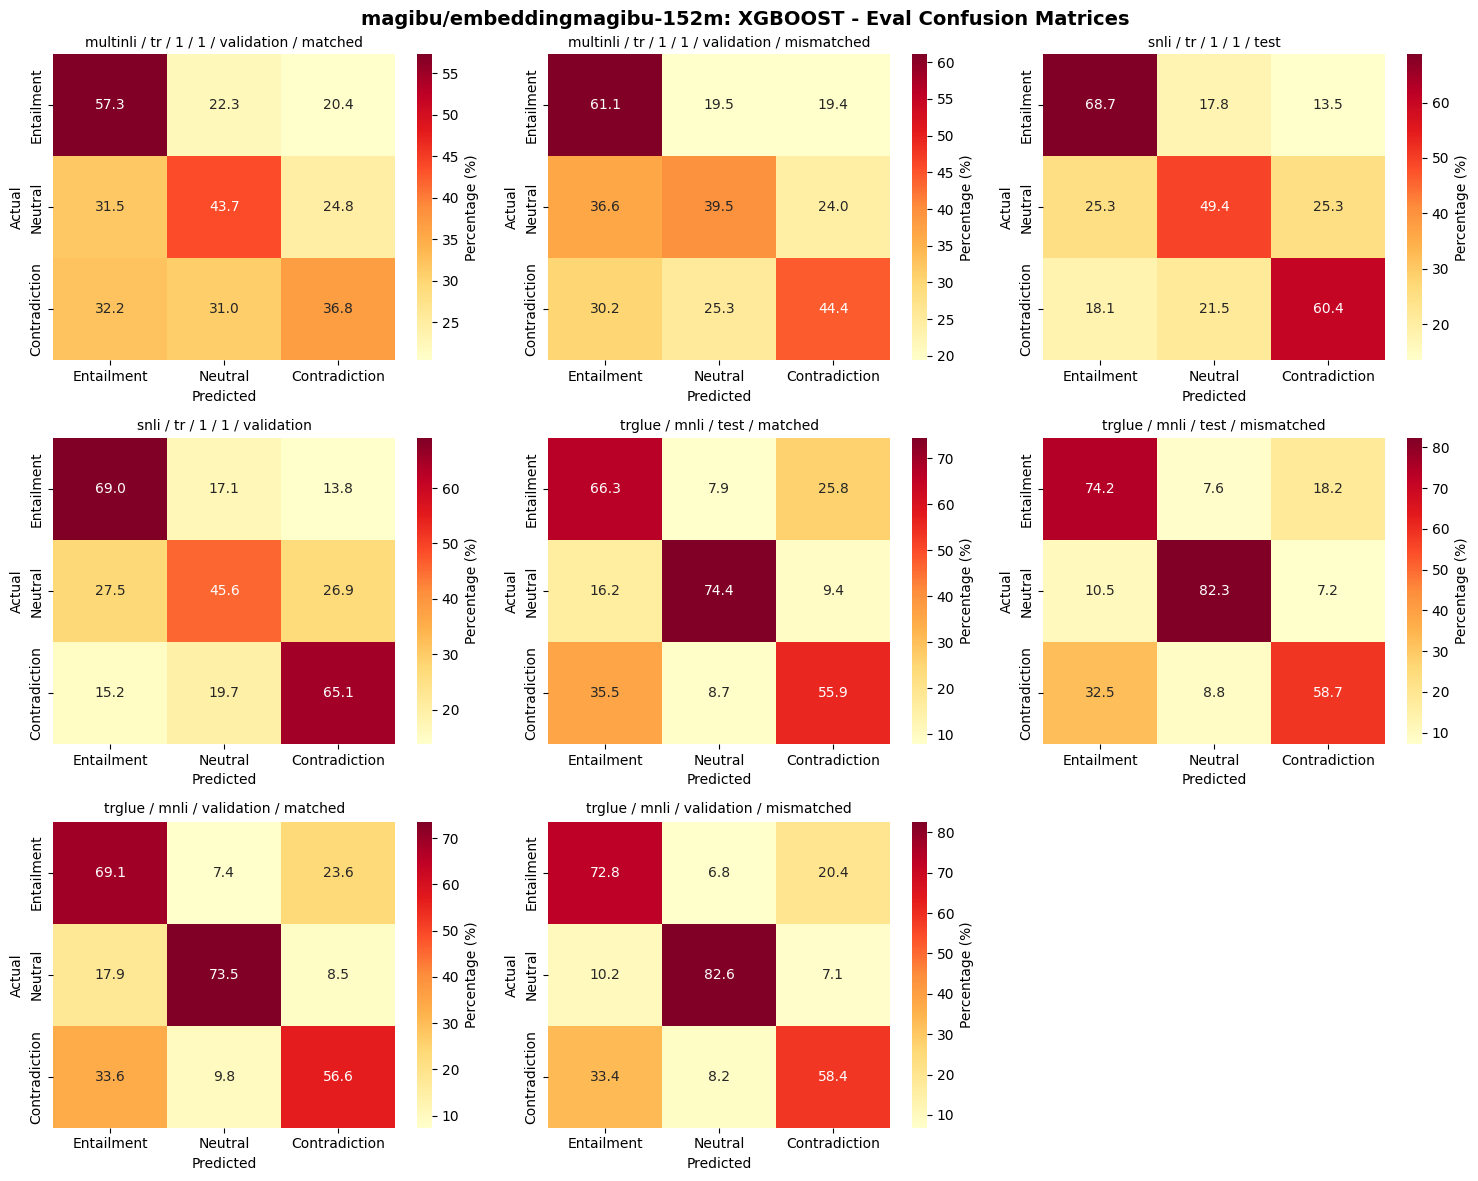

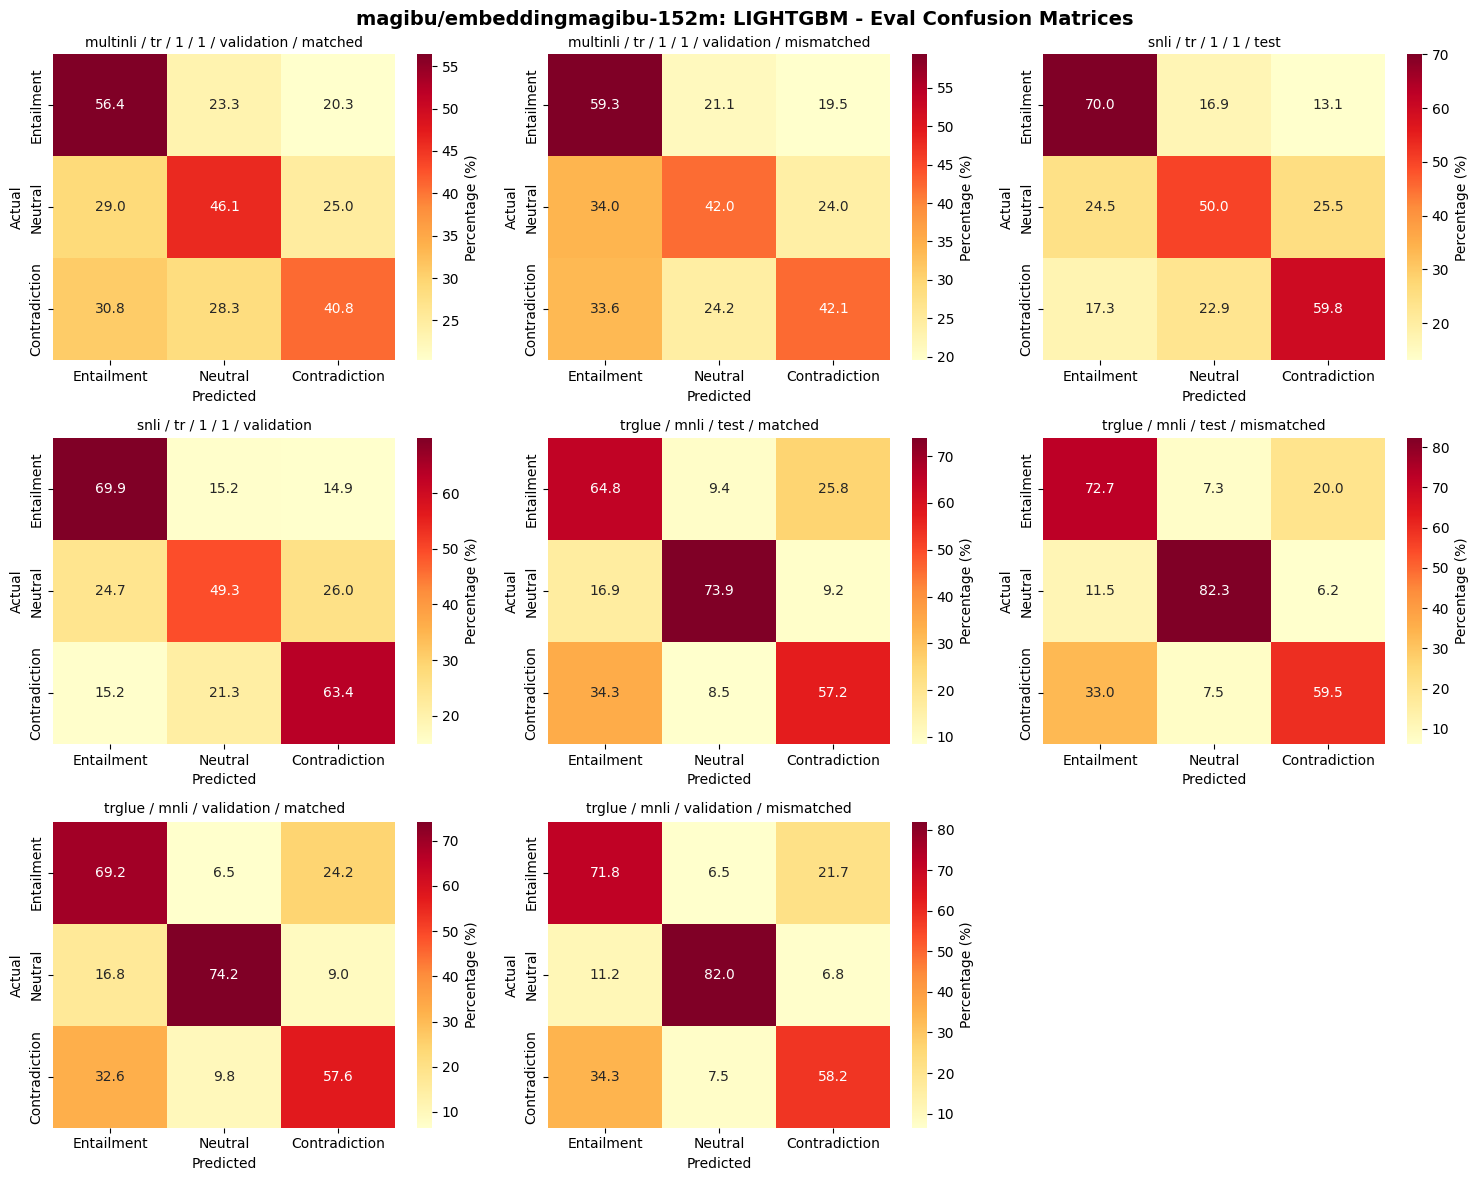

In [63]:
print("\n" + "="*70)
print("GENERATING CONFUSION MATRICES - VALIDATION & TEST SPLITS")
print("="*70)

for booster in ['xgboost', 'lightgbm']:
    # Get all confusion matrices except train
    all_files = list(OUTPUT_DIR.glob(f'{booster}_confusion_*.csv'))
    files = [f for f in all_files if 'train' not in f.name]

    if not files:
        print(f"No test confusion matrices found for {booster}")
        continue

    n_files = len(files)
    n_cols = min(3, n_files)
    n_rows = (n_files + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    fig.suptitle(f'{EMBEDDING_MODEL_NAME}: {booster.upper()} - Eval Confusion Matrices',
                 fontsize=14, fontweight='bold')

    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, cm_path in enumerate(sorted(files)):
        row, col = idx // n_cols, idx % n_cols
        # Extract clean name from filename
        name = cm_path.stem.replace(f'{booster}_confusion_', '').replace('_', ' / ')
        plot_confusion_heatmap(cm_path, name, axes[row, col], normalize=True)  # CHANGED to normalize=True

    # Hide unused subplots
    for idx in range(n_files, n_rows * n_cols):
        row, col = idx // n_cols, idx % n_cols
        axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'confusion_eval_{booster}.png', dpi=300, bbox_inches='tight')
    plt.show()


BEST PERFORMING SPLIT - NORMALIZED CONFUSION MATRIX


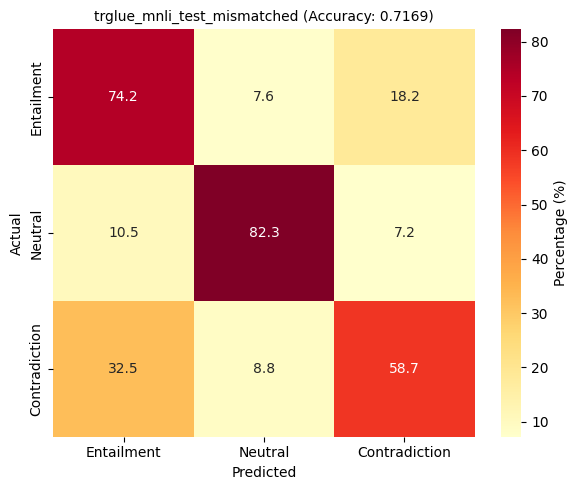

✅ Best performing split: trglue_mnli_test_mismatched with accuracy 0.7169


In [64]:
print("\n" + "="*70)
print("BEST PERFORMING SPLIT - NORMALIZED CONFUSION MATRIX")
print("="*70)

# Find best performing test split
best_acc = 0
best_cm_path = None
best_name = ""

for cm_path in OUTPUT_DIR.glob('*_confusion_*.csv'):
    if 'train' in cm_path.name: continue
    cm = np.loadtxt(cm_path, delimiter=',', skiprows=1)
    acc = np.trace(cm) / np.sum(cm)
    if acc > best_acc:
        best_acc = acc
        best_cm_path = cm_path
        best_name = cm_path.stem.replace('xgboost_confusion_', '').replace('lightgbm_confusion_', '')

if best_cm_path:
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_confusion_heatmap(best_cm_path, f'{best_name} (Accuracy: {best_acc:.4f})', ax, normalize=True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'confusion_best_normalized.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Best performing split: {best_name} with accuracy {best_acc:.4f}")


## Section 9.1: Out-of-Domain (OOD) Generalization Analysis

### Domain Mismatch: Matched vs Mismatched
**Why important for Turkish NLI?**
- **Matched**: Test data similar to training data domain → shows memorization
- **Mismatched**: Test data from different domains → shows true generalization
- Large gap = **poor generalization** | Small gap = **good robustness**



OUT-OF-DOMAIN (OOD) GENERALIZATION ANALYSIS

Measures model robustness to domain shift (matched vs mismatched splits)

📊 MultiNLI-TR:
  XGBOOST  | Matched: 0.4623 | Mismatched: 0.4870 | Δ: -0.0247 | ✅ Good
  LIGHTGBM | Matched: 0.4801 | Mismatched: 0.4814 | Δ: -0.0013 | ✅ Good

📊 TRGLUE-MNLI:
  XGBOOST  | Matched: 0.6570 | Mismatched: 0.7169 | Δ: -0.0599 | ✅ Good
  LIGHTGBM | Matched: 0.6548 | Mismatched: 0.7148 | Δ: -0.0599 | ✅ Good

✅ OOD analysis visualization saved to /content/results_embedding_magibu_152m/ood_domain_mismatch_analysis.png


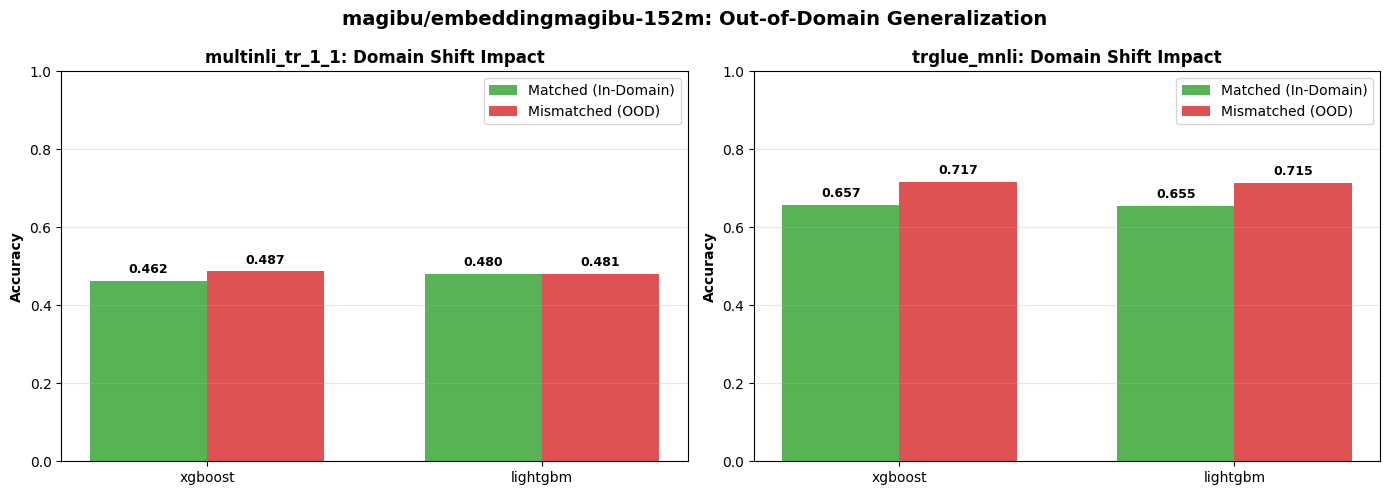

In [65]:
print("\n" + "="*70)
print("OUT-OF-DOMAIN (OOD) GENERALIZATION ANALYSIS")
print("="*70)
print("\nMeasures model robustness to domain shift (matched vs mismatched splits)\n")

ood_analysis = []

# Multi-NLI
if 'validation_matched' in DATASETS_CONFIG['multinli_tr_1_1']['splits'] and \
   'validation_mismatched' in DATASETS_CONFIG['multinli_tr_1_1']['splits']:

    print("📊 MultiNLI-TR:")
    for booster_name in ['xgboost', 'lightgbm']:
        matched_acc = lightgbm_results['multinli_tr_1_1']['validation_matched']['accuracy'] if booster_name == 'lightgbm' else xgboost_results['multinli_tr_1_1']['validation_matched']['accuracy']
        mismatched_acc = lightgbm_results['multinli_tr_1_1']['validation_mismatched']['accuracy'] if booster_name == 'lightgbm' else xgboost_results['multinli_tr_1_1']['validation_mismatched']['accuracy']

        if booster_name == 'xgboost':
            matched_acc = xgboost_results['multinli_tr_1_1']['validation_matched']['accuracy']
            mismatched_acc = xgboost_results['multinli_tr_1_1']['validation_mismatched']['accuracy']
        else:
            matched_acc = lightgbm_results['multinli_tr_1_1']['validation_matched']['accuracy']
            mismatched_acc = lightgbm_results['multinli_tr_1_1']['validation_mismatched']['accuracy']

        delta = matched_acc - mismatched_acc
        resilience = "✅ Good" if delta < 0.05 else "⚠️ Medium" if delta < 0.10 else "❌ Poor"

        print(f"  {booster_name.upper():8} | Matched: {matched_acc:.4f} | Mismatched: {mismatched_acc:.4f} | Δ: {delta:.4f} | {resilience}")
        ood_analysis.append({
            'Dataset': 'multinli_tr_1_1',
            'Booster': booster_name,
            'Matched': round(matched_acc, 4),
            'Mismatched': round(mismatched_acc, 4),
            'Delta': round(delta, 4),
            'Resilience': resilience
        })

# TRGLUE-MNLI
if 'test_matched' in DATASETS_CONFIG['trglue_mnli']['splits'] and \
   'test_mismatched' in DATASETS_CONFIG['trglue_mnli']['splits']:

    print("\n📊 TRGLUE-MNLI:")
    for booster_name in ['xgboost', 'lightgbm']:
        if booster_name == 'xgboost':
            matched_acc = xgboost_results['trglue_mnli']['test_matched']['accuracy']
            mismatched_acc = xgboost_results['trglue_mnli']['test_mismatched']['accuracy']
        else:
            matched_acc = lightgbm_results['trglue_mnli']['test_matched']['accuracy']
            mismatched_acc = lightgbm_results['trglue_mnli']['test_mismatched']['accuracy']

        delta = matched_acc - mismatched_acc
        resilience = "✅ Good" if delta < 0.05 else "⚠️ Medium" if delta < 0.10 else "❌ Poor"

        print(f"  {booster_name.upper():8} | Matched: {matched_acc:.4f} | Mismatched: {mismatched_acc:.4f} | Δ: {delta:.4f} | {resilience}")
        ood_analysis.append({
            'Dataset': 'trglue_mnli',
            'Booster': booster_name,
            'Matched': round(matched_acc, 4),
            'Mismatched': round(mismatched_acc, 4),
            'Delta': round(delta, 4),
            'Resilience': resilience
        })

if ood_analysis:
    # Visualization
    df_ood = pd.DataFrame(ood_analysis)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Domain Performance Comparison
    datasets = df_ood['Dataset'].unique()
    for idx, dataset in enumerate(datasets):
        ax = axes[idx]
        data_subset = df_ood[df_ood['Dataset'] == dataset]

        boosters = data_subset['Booster'].values
        matched = data_subset['Matched'].values
        mismatched = data_subset['Mismatched'].values

        x = np.arange(len(boosters))
        w = 0.35

        ax.bar(x - w/2, matched, w, label='Matched (In-Domain)', alpha=0.8, color='#2ca02c')
        ax.bar(x + w/2, mismatched, w, label='Mismatched (OOD)', alpha=0.8, color='#d62728')

        ax.set_ylabel('Accuracy', fontweight='bold')
        ax.set_title(f'{dataset}: Domain Shift Impact', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(boosters)
        ax.legend()
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)

        # Add value labels
        for i, (m, mis) in enumerate(zip(matched, mismatched)):
            ax.text(i - w/2, m + 0.02, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
            ax.text(i + w/2, mis + 0.02, f'{mis:.3f}', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle(f'{EMBEDDING_MODEL_NAME}: Out-of-Domain Generalization',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    ood_path = OUTPUT_DIR / 'ood_domain_mismatch_analysis.png'
    plt.savefig(ood_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ OOD analysis visualization saved to {ood_path}")
    plt.show()


## Section 10: Per-Label Performance Analysis (Entailment, Neutral, Contradiction)

### Analysis Method: Using Confusion Matrices from Model Results
**IMPORTANT**: This section calculates per-label metrics directly from confusion matrices saved in Sections 4 & 5.
- Data source: Confusion matrix CSV files (`*_confusion_*.csv`)
- Method: Aggregate all confusion matrices and compute per-label precision/recall/F1
- This ensures per-label metrics exactly match the overall model performance
- Full datasets are used for both train and test splits


In [66]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*70)
print("PER-LABEL PERFORMANCE ANALYSIS")
print("="*70)
print(f"\n📊 Data Source: Confusion matrix CSV files from Sections 4 & 5")
print(f"📁 Results directory: {OUTPUT_DIR}\n")

def calculate_per_label_metrics_from_cms(booster_type):
    """Calculate per-label metrics directly from confusion matrices."""
    total_cm = np.zeros((3, 3))

    print(f"Loading {booster_type.upper()} confusion matrices...")
    cm_count = 0

    for dataset_name, config in DATASETS_CONFIG.items():
        for split in config['splits']:
            if split == 'train':
                continue  # Skip train to match Section 4 & 5 logic

            cm_path = OUTPUT_DIR / f'{booster_type}_confusion_{dataset_name}_{split}.csv'

            if cm_path.exists():
                cm = np.loadtxt(cm_path, delimiter=',', skiprows=1)
                total_cm += cm
                cm_count += 1
                print(f"  ✅ {dataset_name:20} | {split:20} | Loaded")

    if cm_count == 0:
        print(f"  ⚠️ No confusion matrices found for {booster_type}!")
        return None, None, None, None

    print(f"  Total CM's aggregated: {cm_count}\n")

    # Calculate per-label metrics from aggregated confusion matrix
    precision_per_label = []
    recall_per_label = []
    f1_per_label = []

    for label in range(3):
        # True Positives
        tp = total_cm[label, label]

        # False Positives: sum of column minus TP
        fp = np.sum(total_cm[:, label]) - tp

        # False Negatives: sum of row minus TP
        fn = np.sum(total_cm[label, :]) - tp

        # Calculations
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        precision_per_label.append(precision)
        recall_per_label.append(recall)
        f1_per_label.append(f1)

    return np.array(precision_per_label), np.array(recall_per_label), np.array(f1_per_label), total_cm

print("="*70)
print("AGGREGATING CONFUSION MATRICES")
print("="*70 + "\n")

# Calculate metrics for both boosters
xgb_precision, xgb_recall, xgb_f1, xgb_total_cm = calculate_per_label_metrics_from_cms('xgboost')
lgb_precision, lgb_recall, lgb_f1, lgb_total_cm = calculate_per_label_metrics_from_cms('lightgbm')



PER-LABEL PERFORMANCE ANALYSIS

📊 Data Source: Confusion matrix CSV files from Sections 4 & 5
📁 Results directory: /content/results_embedding_magibu_152m

AGGREGATING CONFUSION MATRICES

Loading XGBOOST confusion matrices...
  ✅ snli_tr_1_1          | validation           | Loaded
  ✅ snli_tr_1_1          | test                 | Loaded
  ✅ multinli_tr_1_1      | validation_matched   | Loaded
  ✅ multinli_tr_1_1      | validation_mismatched | Loaded
  ✅ trglue_mnli          | validation_matched   | Loaded
  ✅ trglue_mnli          | validation_mismatched | Loaded
  ✅ trglue_mnli          | test_matched         | Loaded
  ✅ trglue_mnli          | test_mismatched      | Loaded
  Total CM's aggregated: 8

Loading LIGHTGBM confusion matrices...
  ✅ snli_tr_1_1          | validation           | Loaded
  ✅ snli_tr_1_1          | test                 | Loaded
  ✅ multinli_tr_1_1      | validation_matched   | Loaded
  ✅ multinli_tr_1_1      | validation_mismatched | Loaded
  ✅ trglue_mnli     

## Section 10.1

In [67]:
if xgb_precision is not None:
    print("\n" + "="*70)
    print("XGBOOST - PER-LABEL METRICS (Aggregated from Confusion Matrices)")
    print("="*70 + "\n")

    print("Aggregated Confusion Matrix:")
    print(xgb_total_cm.astype(int))
    print()

    # Create report-like output
    xgb_data = []
    total_samples = 0
    for label in range(3):
        tp = xgb_total_cm[label, label]
        fp = np.sum(xgb_total_cm[:, label]) - tp
        fn = np.sum(xgb_total_cm[label, :]) - tp
        support = int(tp + fn)
        total_samples += support

        xgb_data.append({
            'Label': LABEL_NAMES[label],
            'Precision': round(xgb_precision[label], 4),
            'Recall': round(xgb_recall[label], 4),
            'F1-Score': round(xgb_f1[label], 4),
            'Support': support
        })

    xgb_report_df = pd.DataFrame(xgb_data)
    display(xgb_report_df)
    print(f"\nAccuracy: {np.trace(xgb_total_cm) / np.sum(xgb_total_cm):.4f}")
    print(f"Total samples: {total_samples}")
else:
    print("⚠️ XGBoost metrics could not be calculated")



XGBOOST - PER-LABEL METRICS (Aggregated from Confusion Matrices)

Aggregated Confusion Matrix:
[[3450  703  989]
 [1107 3066  842]
 [1432  844 2723]]



,Label,Precision,Recall,F1-Score,Support
0,entailment,0.5761,0.6709,0.6199,5142
1,neutral,0.6646,0.6114,0.6369,5015
2,contradiction,0.5979,0.5447,0.5701,4999



Accuracy: 0.6096
Total samples: 15156


## Section 10.2

In [68]:
if lgb_precision is not None:
    print("\n" + "="*70)
    print("LIGHTGBM - PER-LABEL METRICS (Aggregated from Confusion Matrices)")
    print("="*70 + "\n")

    print("Aggregated Confusion Matrix:")
    print(lgb_total_cm.astype(int))
    print()

    # Create report-like output
    lgb_data = []
    total_samples = 0
    for label in range(3):
        tp = lgb_total_cm[label, label]
        fp = np.sum(lgb_total_cm[:, label]) - tp
        fn = np.sum(lgb_total_cm[label, :]) - tp
        support = int(tp + fn)
        total_samples += support

        lgb_data.append({
            'Label': LABEL_NAMES[label],
            'Precision': round(lgb_precision[label], 4),
            'Recall': round(lgb_recall[label], 4),
            'F1-Score': round(lgb_f1[label], 4),
            'Support': support
        })

    lgb_report_df = pd.DataFrame(lgb_data)
    display(lgb_report_df)
    print(f"\nAccuracy: {np.trace(lgb_total_cm) / np.sum(lgb_total_cm):.4f}")
    print(f"Total samples: {total_samples}")
else:
    print("⚠️ LightGBM metrics could not be calculated")



LIGHTGBM - PER-LABEL METRICS (Aggregated from Confusion Matrices)

Aggregated Confusion Matrix:
[[3424  702 1016]
 [1061 3122  832]
 [1435  827 2737]]



,Label,Precision,Recall,F1-Score,Support
0,entailment,0.5784,0.6659,0.6191,5142
1,neutral,0.6713,0.6225,0.6460,5015
2,contradiction,0.5969,0.5475,0.5712,4999



Accuracy: 0.6125
Total samples: 15156


## Section 10.3

In [69]:
if xgb_precision is not None and lgb_precision is not None:
    print("\n" + "="*70)
    print("PER-LABEL PERFORMANCE COMPARISON")
    print("="*70 + "\n")

    label_comparison = pd.DataFrame({
        'Label': list(LABEL_NAMES.values()),
        'XGB-Precision': np.round(xgb_precision, 4),
        'XGB-Recall': np.round(xgb_recall, 4),
        'XGB-F1': np.round(xgb_f1, 4),
        'LGB-Precision': np.round(lgb_precision, 4),
        'LGB-Recall': np.round(lgb_recall, 4),
        'LGB-F1': np.round(lgb_f1, 4)
    })

    display(label_comparison)
    #print(label_comparison.to_string(index=False))

    # Save to CSV
    label_comp_path = OUTPUT_DIR / 'per_label_performance.csv'
    label_comparison.to_csv(label_comp_path, index=False)
    print(f"\n✅ Per-label metrics saved to {label_comp_path}")
else:
    print("⚠️ Cannot create comparison - metrics unavailable")



PER-LABEL PERFORMANCE COMPARISON



,Label,XGB-Precision,XGB-Recall,XGB-F1,LGB-Precision,LGB-Recall,LGB-F1
0,entailment,0.5761,0.6709,0.6199,0.5784,0.6659,0.6191
1,neutral,0.6646,0.6114,0.6369,0.6713,0.6225,0.6460
2,contradiction,0.5979,0.5447,0.5701,0.5969,0.5475,0.5712



✅ Per-label metrics saved to /content/results_embedding_magibu_152m/per_label_performance.csv


## Section 10.4

In [70]:
if xgb_precision is not None and lgb_precision is not None:
    print("\n" + "="*70)
    print("LABEL-WISE INSIGHTS")
    print("="*70 + "\n")

    for idx, label_name in LABEL_NAMES.items():
        xgb_f1_score = xgb_f1[idx]
        lgb_f1_score = lgb_f1[idx]
        better_model = 'XGBoost' if xgb_f1_score > lgb_f1_score else 'LightGBM'
        delta = abs(xgb_f1_score - lgb_f1_score)

        print(f"{label_name.upper()}:")
        print(f"  XGBoost F1: {xgb_f1_score:.4f} | LightGBM F1: {lgb_f1_score:.4f}")
        print(f"  ► Better: {better_model} (Δ={delta:.4f})")
        print()



LABEL-WISE INSIGHTS

ENTAILMENT:
  XGBoost F1: 0.6199 | LightGBM F1: 0.6191
  ► Better: XGBoost (Δ=0.0008)

NEUTRAL:
  XGBoost F1: 0.6369 | LightGBM F1: 0.6460
  ► Better: LightGBM (Δ=0.0091)

CONTRADICTION:
  XGBoost F1: 0.5701 | LightGBM F1: 0.5712
  ► Better: LightGBM (Δ=0.0011)



## Section 10.5


✅ Per-label bar chart saved to /content/results_embedding_magibu_152m/per_label_performance.png


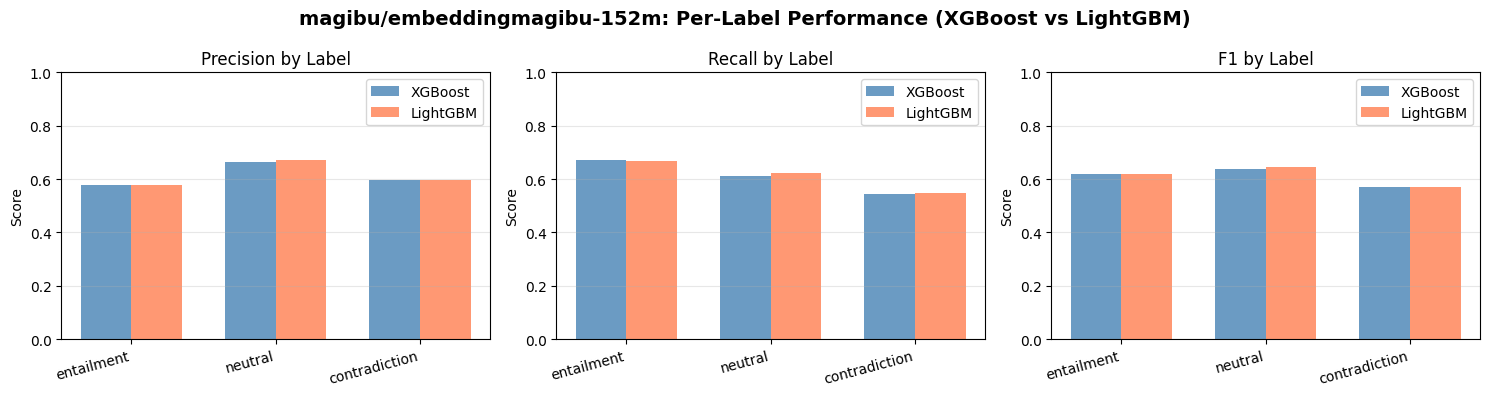


📊 Creating Per-Label Heatmap...


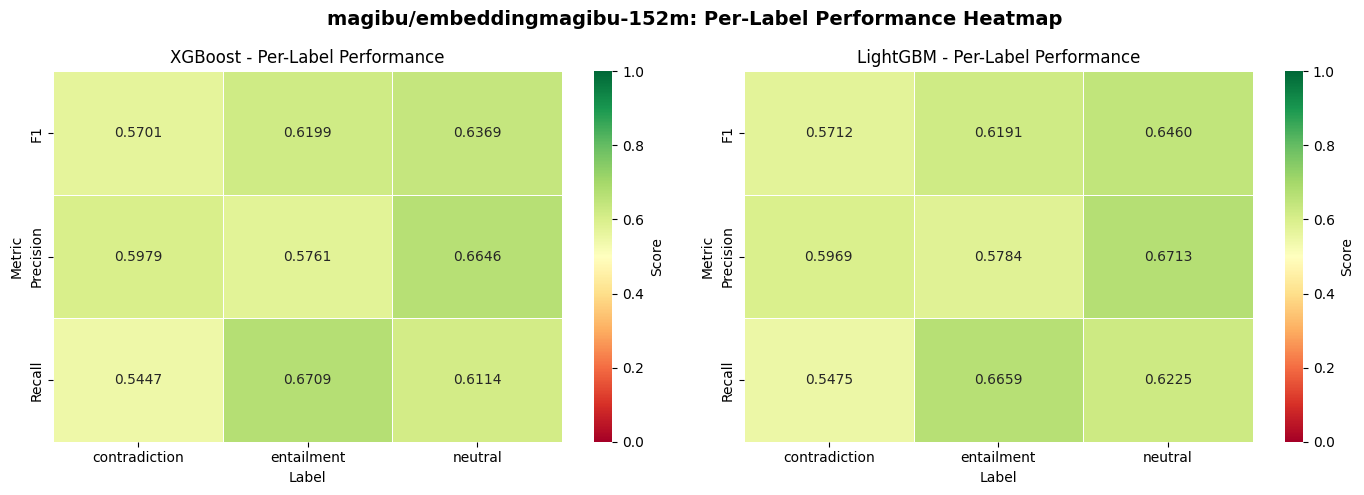

✅ Per-label heatmap saved to /content/results_embedding_magibu_152m/per_label_heatmap.png


In [71]:
if xgb_precision is not None and lgb_precision is not None:
    # Visualize per-label performance
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{EMBEDDING_MODEL_NAME}: Per-Label Performance (XGBoost vs LightGBM)',
                 fontsize=14, fontweight='bold')

    metrics_names = ['Precision', 'Recall', 'F1']
    label_names_list = list(LABEL_NAMES.values())

    for idx, metric_name in enumerate(metrics_names):
        ax = axes[idx]

        if metric_name == 'Precision':
            xgb_vals = xgb_precision
            lgb_vals = lgb_precision
        elif metric_name == 'Recall':
            xgb_vals = xgb_recall
            lgb_vals = lgb_recall
        else:  # F1
            xgb_vals = xgb_f1
            lgb_vals = lgb_f1

        x = np.arange(len(label_names_list))
        w = 0.35

        ax.bar(x - w/2, xgb_vals, w, label='XGBoost', alpha=0.8, color='steelblue')
        ax.bar(x + w/2, lgb_vals, w, label='LightGBM', alpha=0.8, color='coral')

        ax.set_ylabel('Score')
        ax.set_title(f'{metric_name} by Label')
        ax.set_xticks(x)
        ax.set_xticklabels(label_names_list, rotation=15, ha='right')
        ax.legend()
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    per_label_viz_path = OUTPUT_DIR / 'per_label_performance.png'
    plt.savefig(per_label_viz_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Per-label bar chart saved to {per_label_viz_path}")
    plt.show()

    # ============================================
    # PER-LABEL HEATMAP
    # ============================================
    print("\n📊 Creating Per-Label Heatmap...")

    # Create a DataFrame for heatmap
    heatmap_data = []
    for metric_name in ['Precision', 'Recall', 'F1']:
        for label_idx, label_name in enumerate(label_names_list):
            if metric_name == 'Precision':
                xgb_val = xgb_precision[label_idx]
                lgb_val = lgb_precision[label_idx]
            elif metric_name == 'Recall':
                xgb_val = xgb_recall[label_idx]
                lgb_val = lgb_recall[label_idx]
            else:  # F1
                xgb_val = xgb_f1[label_idx]
                lgb_val = lgb_f1[label_idx]

            heatmap_data.append({
                'Metric': metric_name,
                'Label': label_name,
                'XGBoost': xgb_val,
                'LightGBM': lgb_val
            })

    df_heatmap = pd.DataFrame(heatmap_data)

    # Reshape for heatmap (Metrics x Labels for each model separately)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for idx, model in enumerate(['XGBoost', 'LightGBM']):
        ax = axes[idx]
        pivot_data = df_heatmap.pivot(index='Metric', columns='Label', values=model)

        sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn',
                    cbar_kws={'label': 'Score'}, ax=ax,
                    linewidths=0.5, vmin=0, vmax=1)
        ax.set_title(f'{model} - Per-Label Performance')
        ax.set_xlabel('Label')
        ax.set_ylabel('Metric')

    plt.suptitle(f'{EMBEDDING_MODEL_NAME}: Per-Label Performance Heatmap',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    per_label_heatmap_path = OUTPUT_DIR / 'per_label_heatmap.png'
    plt.savefig(per_label_heatmap_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Per-label heatmap saved to {per_label_heatmap_path}")

else:
    print("⚠️ Cannot create visualizations - metrics unavailable")


## Section 10.6: Semantic Error Analysis

### Which logical relationships does the model struggle with?
NLI is fundamentally a logical task. Understanding WHERE the model fails reveals systematic biases:
- **Low Recall** = Model misses certain patterns (False Negatives)
- **High False Positive Rate** = Model confuses two different label types



SEMANTIC ERROR ANALYSIS - Model Confusion Patterns


📊 XGBOOST: Error Patterns

        Label   TP   FN   FP Recall FP_Rate Most_Confused_With  Confusion_Count
   entailment 3450 1692 2539 0.6709  0.2535      contradiction              989
      neutral 3066 1949 1547 0.6114  0.1525         entailment             1107
contradiction 2723 2276 1831 0.5447  0.1803         entailment             1432

🔴 WEAKEST POINT: Model struggles most with 'contradiction' (Recall: 0.5447)
   → Frequently confuses 'contradiction' with 'entailment' (1432 times)


📊 LIGHTGBM: Error Patterns

        Label   TP   FN   FP Recall FP_Rate Most_Confused_With  Confusion_Count
   entailment 3424 1718 2496 0.6659  0.2493      contradiction             1016
      neutral 3122 1893 1529 0.6225  0.1508         entailment             1061
contradiction 2737 2262 1848 0.5475  0.1819         entailment             1435

🔴 WEAKEST POINT: Model struggles most with 'contradiction' (Recall: 0.5475)
   → Frequently confuse

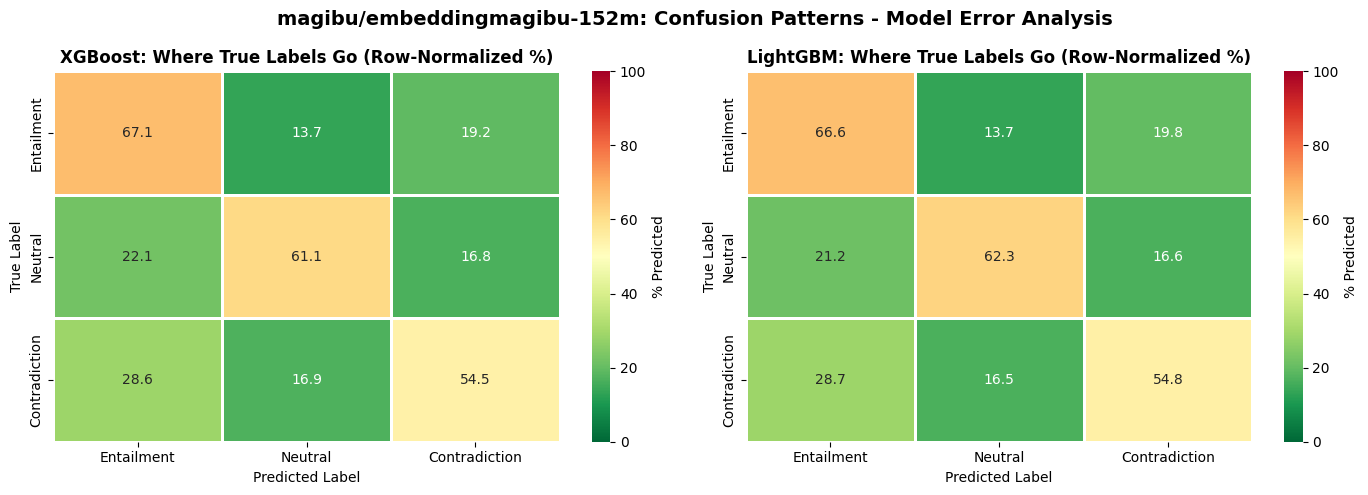

In [72]:
if xgb_precision is not None and lgb_precision is not None:
    print("\n" + "="*70)
    print("SEMANTIC ERROR ANALYSIS - Model Confusion Patterns")
    print("="*70 + "\n")

    for booster_name, total_cm in [('XGBoost', xgb_total_cm), ('LightGBM', lgb_total_cm)]:
        print(f"\n📊 {booster_name.upper()}: Error Patterns\n")

        # Calculate error metrics per label
        error_data = []
        for label_idx, label_name in LABEL_NAMES.items():
            # True Positives (correctly identified)
            tp = total_cm[label_idx, label_idx]

            # False Negatives (missed - model said something else)
            fn = np.sum(total_cm[label_idx, :]) - tp

            # False Positives (false alarm - model predicted this but was wrong)
            fp = np.sum(total_cm[:, label_idx]) - tp

            # What does the model CONFUSE this label with? Find the most common confusion
            row = total_cm[label_idx, :]
            most_confused_idx = np.argmax([row[i] if i != label_idx else 0 for i in range(len(row))])
            most_confused_label = LABEL_NAMES[most_confused_idx]
            confusion_count = int(row[most_confused_idx])

            # Recall (what % of true instances are caught)
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0

            # False Positive Rate (how often we wrongly predict this)
            total_negatives = np.sum(total_cm) - np.sum(total_cm[label_idx, :])
            fp_rate = fp / total_negatives if total_negatives > 0 else 0

            error_data.append({
                'Label': label_name,
                'TP': int(tp),
                'FN': int(fn),
                'FP': int(fp),
                'Recall': f'{recall:.4f}',
                'FP_Rate': f'{fp_rate:.4f}',
                'Most_Confused_With': most_confused_label,
                'Confusion_Count': confusion_count
            })

        error_df = pd.DataFrame(error_data)
        print(error_df.to_string(index=False))
        print()

        # Find the weakest label (lowest recall)
        recalls = [float(error_data[i]['Recall']) for i in range(3)]
        weakest_idx = np.argmin(recalls)
        weakest_label = LABEL_NAMES[weakest_idx]
        weakest_recall = recalls[weakest_idx]

        # Find most confused pair
        max_confusion = max(error_data, key=lambda x: x['Confusion_Count'])

        print(f"🔴 WEAKEST POINT: Model struggles most with '{weakest_label}' (Recall: {weakest_recall:.4f})")
        print(f"   → Frequently confuses '{max_confusion['Label']}' with '{max_confusion['Most_Confused_With']}' ({max_confusion['Confusion_Count']} times)")
        print()

    # Visualization: Error Heatmap
    print("Creating Error Pattern Heatmap...\n")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for idx, (booster_name, total_cm) in enumerate([('XGBoost', xgb_total_cm), ('LightGBM', lgb_total_cm)]):
        ax = axes[idx]

        # Normalize by row (what % went to each predicted label)
        cm_normalized = total_cm.astype('float') / total_cm.sum(axis=1)[:, np.newaxis] * 100

        sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='RdYlGn_r',
                   xticklabels=['Entailment', 'Neutral', 'Contradiction'],
                   yticklabels=['Entailment', 'Neutral', 'Contradiction'],
                   ax=ax, cbar_kws={'label': '% Predicted'},
                   vmin=0, vmax=100, linewidths=1)

        ax.set_title(f'{booster_name}: Where True Labels Go (Row-Normalized %)', fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

    plt.suptitle(f'{EMBEDDING_MODEL_NAME}: Confusion Patterns - Model Error Analysis',
                fontsize=14, fontweight='bold')
    plt.tight_layout()

    error_analysis_path = OUTPUT_DIR / 'semantic_error_analysis.png'
    plt.savefig(error_analysis_path, dpi=300, bbox_inches='tight')
    print(f"✅ Semantic error analysis saved to {error_analysis_path}\n")
    plt.show()


## Section 11: Feature Importance Analysis

### What makes the model decide?
Are raw embedding dimensions more important, or our engineered similarity/distance features?
This reveals whether the model relies on semantic understanding or pattern matching.



FEATURE IMPORTANCE ANALYSIS

✅ Feature importance saved to /content/results_embedding_magibu_152m/feature_importance.png



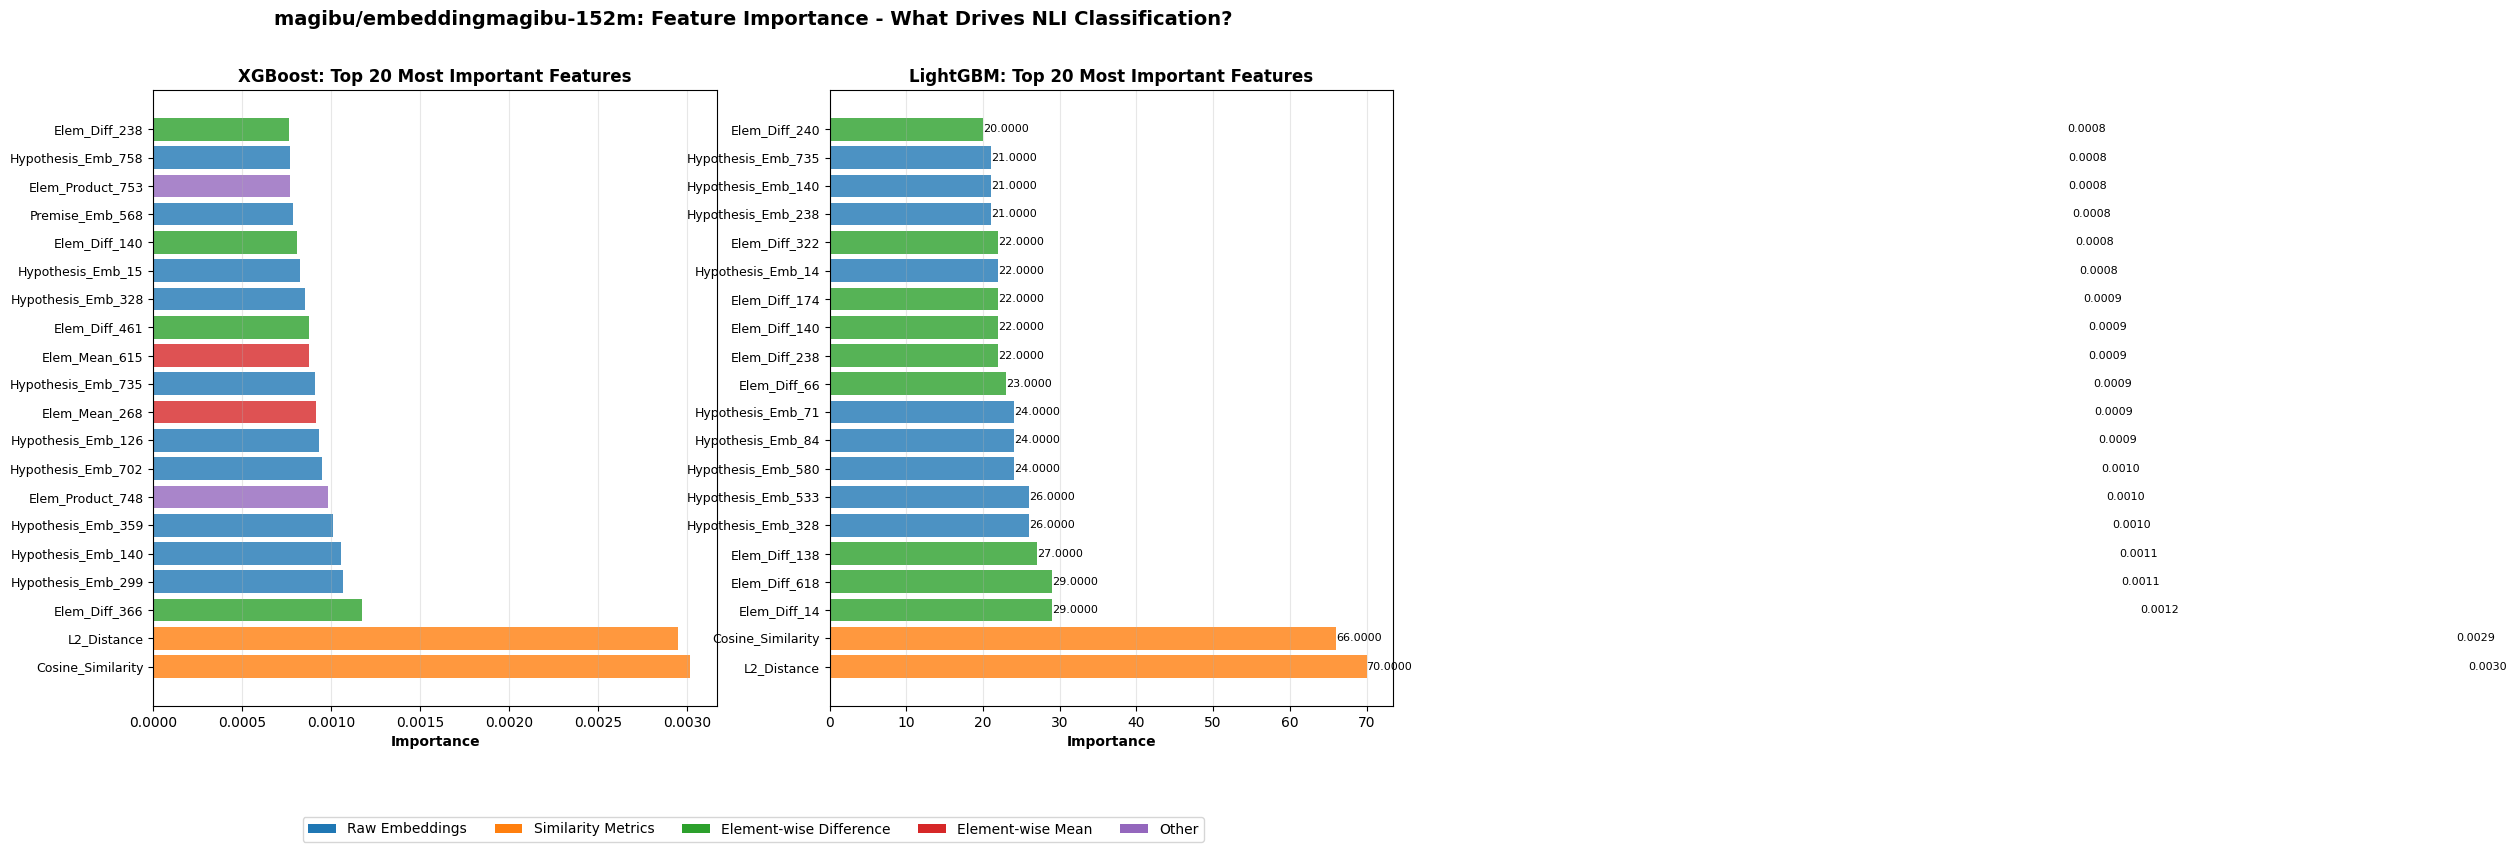

Feature Category Importance Breakdown:

Raw Embeddings                 | XGB: 0.3865 | LGB: 3460.0000
Element-wise Difference        | XGB: 0.2331 | LGB: 2952.0000
Element-wise Mean              | XGB: 0.1925 | LGB: 1026.0000
Similarity Metrics             | XGB: 0.0061 | LGB: 136.0000
Element-wise Product           | XGB: 0.1818 | LGB: 1359.0000


In [73]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70 + "\n")

# Get one model from each booster to analyze feature importance
xgb_model = None
lgb_model = None

for dataset_name in DATASETS_CONFIG.keys():
    for split in DATASETS_CONFIG[dataset_name]['splits']:
        if split != 'train' and xgb_model is None:
            xgb_model = xgboost_results[dataset_name][split].get('model')
            lgb_model = lightgbm_results[dataset_name][split].get('model')
            break
    if xgb_model is not None:
        break

if xgb_model is not None:
    # Feature names mapping
    EMBEDDING_DIM = 768
    n_raw_features = 2 * EMBEDDING_DIM  # Premise + Hypothesis embeddings

    # Calculate feature categories
    feature_categories = {}
    feature_names = []

    # Raw embeddings (0 to n_raw_features-1)
    for i in range(n_raw_features):
        emb_type = 'Premise' if i < EMBEDDING_DIM else 'Hypothesis'
        dim_idx = i % EMBEDDING_DIM
        feature_names.append(f'{emb_type}_Emb_{dim_idx}')
        feature_categories[f'{emb_type}_Emb_{dim_idx}'] = 'Raw Embeddings'

    # Engineered features
    engineered_features = [
        'Cosine_Similarity', 'L2_Distance',
        'Norm_Diff', 'Norm_Ratio'
    ] + [f'Elem_Diff_{i}' for i in range(EMBEDDING_DIM)] + \
        [f'Elem_Mean_{i}' for i in range(EMBEDDING_DIM)] + \
        [f'Elem_Product_{i}' for i in range(EMBEDDING_DIM)]

    for feat in engineered_features:
        feature_names.append(feat)
        if 'Elem' in feat:
            if 'Diff' in feat:
                feature_categories[feat] = 'Element-wise Difference'
            elif 'Mean' in feat:
                feature_categories[feat] = 'Element-wise Mean'
            else:
                feature_categories[feat] = 'Element-wise Product'
        else:
            feature_categories[feat] = 'Similarity Metrics'

    # Get top 20 features
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for idx, (model_name, model) in enumerate([('XGBoost', xgb_model), ('LightGBM', lgb_model)]):
        ax = axes[idx]

        importances = model.feature_importances_

        # Get top 20
        top_indices = np.argsort(importances)[-20:][::-1]
        top_importances = importances[top_indices]
        top_names = [feature_names[i] if i < len(feature_names) else f'Feature_{i}' for i in top_indices]

        # Color code by category
        colors = []
        for feat_name in top_names:
            if 'Emb' in feat_name:
                colors.append('#1f77b4')  # Blue
            elif 'Similarity' in feature_categories.get(feat_name, ''):
                colors.append('#ff7f0e')  # Orange
            elif 'Difference' in feature_categories.get(feat_name, ''):
                colors.append('#2ca02c')  # Green
            elif 'Mean' in feature_categories.get(feat_name, ''):
                colors.append('#d62728')  # Red
            else:
                colors.append('#9467bd')  # Purple

        ax.barh(range(len(top_importances)), top_importances, color=colors, alpha=0.8)
        ax.set_yticks(range(len(top_names)))
        ax.set_yticklabels(top_names, fontsize=9)
        ax.set_xlabel('Importance', fontweight='bold')
        ax.set_title(f'{model_name}: Top 20 Most Important Features', fontweight='bold', fontsize=12)
        ax.grid(axis='x', alpha=0.3)

        # Add value labels
        for i, v in enumerate(top_importances):
            ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=8)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='Raw Embeddings'),
        Patch(facecolor='#ff7f0e', label='Similarity Metrics'),
        Patch(facecolor='#2ca02c', label='Element-wise Difference'),
        Patch(facecolor='#d62728', label='Element-wise Mean'),
        Patch(facecolor='#9467bd', label='Other')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=5)

    plt.suptitle(f'{EMBEDDING_MODEL_NAME}: Feature Importance - What Drives NLI Classification?',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 1])

    feature_imp_path = OUTPUT_DIR / 'feature_importance.png'
    plt.savefig(feature_imp_path, dpi=300, bbox_inches='tight')
    print(f"✅ Feature importance saved to {feature_imp_path}\n")
    plt.show()

    # Summary statistics
    print("Feature Category Importance Breakdown:\n")
    for category in set(feature_categories.values()):
        indices = [i for i, feat in enumerate(feature_names)
                  if feature_categories.get(feat, '') == category]
        if indices:
            cat_importance_xgb = np.sum(xgb_model.feature_importances_[indices])
            cat_importance_lgb = np.sum(lgb_model.feature_importances_[indices]) if lgb_model else 0
            print(f"{category:30} | XGB: {cat_importance_xgb:.4f} | LGB: {cat_importance_lgb:.4f}")


## Section 12: Confidence vs Correctness Analysis

### When is the model overconfident?
High confidence with wrong predictions = adversarial examples that fool the model.
Low confidence with correct predictions = uncertain but accurate.



CONFIDENCE VS CORRECTNESS ANALYSIS

High Confidence (>0.90): 1728 Correct | 84 Wrong
Medium Confidence (0.60-0.90): 3988 Correct | 1790 Wrong
Low Confidence (<0.60): 3523 Correct | 4043 Wrong

🚨 ADVERSARIAL EXAMPLES FOUND: 84 high-confidence WRONG predictions
   Model is >90% confident but still wrong - indicates adversarial/tricky examples

✅ Confidence analysis saved to /content/results_embedding_magibu_152m/confidence_vs_correctness.png



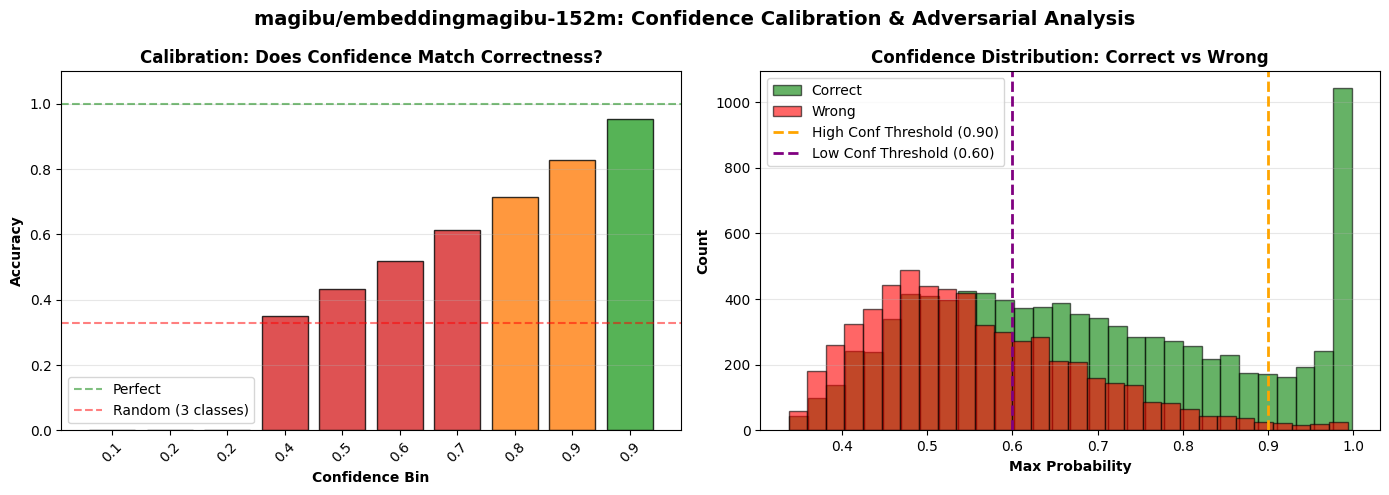

✅ ANALYSIS COMPLETE


In [74]:
print("\n" + "="*70)
print("CONFIDENCE VS CORRECTNESS ANALYSIS")
print("="*70 + "\n")

# Collect all predictions with confidence scores
all_y_true = []
all_y_pred = []
all_max_proba = []
all_dataset_names = []
all_split_names = []

for dataset_name in DATASETS_CONFIG.keys():
    for split in DATASETS_CONFIG[dataset_name]['splits']:
        if split != 'train':
            xgb_data = xgboost_results[dataset_name][split]
            if 'y_test' in xgb_data:
                all_y_true.extend(xgb_data['y_test'])
                all_y_pred.extend(xgb_data['y_pred'])
                all_max_proba.extend(np.max(xgb_data['y_proba'], axis=1))
                all_dataset_names.extend([dataset_name] * len(xgb_data['y_test']))
                all_split_names.extend([split] * len(xgb_data['y_test']))

if len(all_y_true) > 0:
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_max_proba = np.array(all_max_proba)

    # Categorize predictions
    correct = (all_y_true == all_y_pred)

    # High confidence (>0.90)
    high_conf_correct = np.sum((all_max_proba > 0.90) & correct)
    high_conf_wrong = np.sum((all_max_proba > 0.90) & ~correct)

    # Low confidence (<0.60)
    low_conf_correct = np.sum((all_max_proba < 0.60) & correct)
    low_conf_wrong = np.sum((all_max_proba < 0.60) & ~correct)

    # Medium confidence (0.60-0.90)
    med_conf_correct = np.sum((all_max_proba >= 0.60) & (all_max_proba <= 0.90) & correct)
    med_conf_wrong = np.sum((all_max_proba >= 0.60) & (all_max_proba <= 0.90) & ~correct)

    print(f"High Confidence (>0.90): {high_conf_correct} Correct | {high_conf_wrong} Wrong")
    print(f"Medium Confidence (0.60-0.90): {med_conf_correct} Correct | {med_conf_wrong} Wrong")
    print(f"Low Confidence (<0.60): {low_conf_correct} Correct | {low_conf_wrong} Wrong\n")

    # Adversarial examples (high conf wrong)
    if high_conf_wrong > 0:
        print(f"🚨 ADVERSARIAL EXAMPLES FOUND: {high_conf_wrong} high-confidence WRONG predictions")
        print(f"   Model is >90% confident but still wrong - indicates adversarial/tricky examples\n")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Confidence bins
    ax = axes[0]
    bins = np.linspace(0, 1, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_correct = []
    bin_total = []

    for i in range(len(bins)-1):
        mask = (all_max_proba >= bins[i]) & (all_max_proba < bins[i+1])
        bin_total.append(np.sum(mask))
        bin_correct.append(np.sum(mask & correct))

    bin_accuracy = np.array([c/t if t > 0 else 0 for c, t in zip(bin_correct, bin_total)])

    colors_conf = ['#d62728' if acc < 0.7 else '#ff7f0e' if acc < 0.85 else '#2ca02c' for acc in bin_accuracy]
    ax.bar(range(len(bin_centers)), bin_accuracy, color=colors_conf, alpha=0.8, edgecolor='black')
    ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect')
    ax.axhline(y=0.33, color='red', linestyle='--', alpha=0.5, label='Random (3 classes)')
    ax.set_xlabel('Confidence Bin', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title('Calibration: Does Confidence Match Correctness?', fontweight='bold')
    ax.set_xticks(range(len(bin_centers)))
    ax.set_xticklabels([f'{b:.1f}' for b in bin_centers], rotation=45)
    ax.set_ylim([0, 1.1])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Plot 2: Confidence distribution by correctness
    ax = axes[1]
    ax.hist(all_max_proba[correct], bins=30, alpha=0.6, label='Correct', color='green', edgecolor='black')
    ax.hist(all_max_proba[~correct], bins=30, alpha=0.6, label='Wrong', color='red', edgecolor='black')
    ax.axvline(x=0.90, color='orange', linestyle='--', linewidth=2, label='High Conf Threshold (0.90)')
    ax.axvline(x=0.60, color='purple', linestyle='--', linewidth=2, label='Low Conf Threshold (0.60)')
    ax.set_xlabel('Max Probability', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title('Confidence Distribution: Correct vs Wrong', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle(f'{EMBEDDING_MODEL_NAME}: Confidence Calibration & Adversarial Analysis',
                fontsize=14, fontweight='bold')
    plt.tight_layout()

    confidence_path = OUTPUT_DIR / 'confidence_vs_correctness.png'
    plt.savefig(confidence_path, dpi=300, bbox_inches='tight')
    print(f"✅ Confidence analysis saved to {confidence_path}\n")
    plt.show()

print('✅ ANALYSIS COMPLETE')


## Section 13: Export for Comparison

### Prepare results for cross-embedder comparison
Export aggregated metrics, per-label performance, and OOD analysis for "Compare All Embedders" notebook


In [75]:
print("\n" + "="*70)
print("EXPORTING RESULTS FOR EMBEDDER COMPARISON")
print("="*70 + "\n")

# Comprehensive export including all key metrics
export_data = {
    'model_name': EMBEDDING_MODEL_NAME,
    'model_short': model_config['name_short'],
    'emoji_description': model_config['desc'],
    'export_timestamp': pd.Timestamp.now().isoformat(),

    # SECTION 7: Overall Summary
    'overall_summary': {
        'xgboost_vs_lightgbm': all_results  # From Section 7
    },

    # SECTION 8: Per-Split Performance
    'per_split_performance': {
        dataset: {
            split: {
                'xgboost': {
                    'accuracy': float(xgboost_results[dataset][split]['accuracy']),
                    'f1_macro': float(xgboost_results[dataset][split]['f1_macro']),
                    'precision_macro': float(xgboost_results[dataset][split]['precision_macro']),
                    'recall_macro': float(xgboost_results[dataset][split]['recall_macro']),
                    'n_samples': int(xgboost_results[dataset][split]['n_samples'])
                },
                'lightgbm': {
                    'accuracy': float(lightgbm_results[dataset][split]['accuracy']),
                    'f1_macro': float(lightgbm_results[dataset][split]['f1_macro']),
                    'precision_macro': float(lightgbm_results[dataset][split]['precision_macro']),
                    'recall_macro': float(lightgbm_results[dataset][split]['recall_macro']),
                    'n_samples': int(lightgbm_results[dataset][split]['n_samples'])
                }
            }
            for split in DATASETS_CONFIG[dataset]['splits']
        }
        for dataset in DATASETS_CONFIG.keys()
    },

    # SECTION 8.5: Dataset Difficulty
    'dataset_difficulty_ranking': [
        {
            'dataset': dataset,
            'avg_accuracy': float(perf['avg_accuracy']),
            'difficulty_level': 'HARD' if perf['avg_accuracy'] < 0.50 else 'MEDIUM' if perf['avg_accuracy'] < 0.65 else 'EASY'
        }
        for dataset, perf in ranked_datasets
    ],

    # SECTION 9.1: OOD Analysis
    'ood_generalization': {
        'multinli': {
            'xgboost': {
                'matched': float(xgboost_results['multinli_tr_1_1']['validation_matched']['accuracy']),
                'mismatched': float(xgboost_results['multinli_tr_1_1']['validation_mismatched']['accuracy']),
                'delta': float(xgboost_results['multinli_tr_1_1']['validation_matched']['accuracy'] -
                              xgboost_results['multinli_tr_1_1']['validation_mismatched']['accuracy']),
            } if 'validation_matched' in DATASETS_CONFIG['multinli_tr_1_1']['splits'] else {},
            'lightgbm': {
                'matched': float(lightgbm_results['multinli_tr_1_1']['validation_matched']['accuracy']),
                'mismatched': float(lightgbm_results['multinli_tr_1_1']['validation_mismatched']['accuracy']),
                'delta': float(lightgbm_results['multinli_tr_1_1']['validation_matched']['accuracy'] -
                              lightgbm_results['multinli_tr_1_1']['validation_mismatched']['accuracy']),
            } if 'validation_matched' in DATASETS_CONFIG['multinli_tr_1_1']['splits'] else {}
        },
        'trglue': {
            'xgboost': {
                'matched': float(xgboost_results['trglue_mnli']['test_matched']['accuracy']),
                'mismatched': float(xgboost_results['trglue_mnli']['test_mismatched']['accuracy']),
                'delta': float(xgboost_results['trglue_mnli']['test_matched']['accuracy'] -
                              xgboost_results['trglue_mnli']['test_mismatched']['accuracy']),
            } if 'test_matched' in DATASETS_CONFIG['trglue_mnli']['splits'] else {},
            'lightgbm': {
                'matched': float(lightgbm_results['trglue_mnli']['test_matched']['accuracy']),
                'mismatched': float(lightgbm_results['trglue_mnli']['test_mismatched']['accuracy']),
                'delta': float(lightgbm_results['trglue_mnli']['test_matched']['accuracy'] -
                              lightgbm_results['trglue_mnli']['test_mismatched']['accuracy']),
            } if 'test_matched' in DATASETS_CONFIG['trglue_mnli']['splits'] else {}
        }
    },

    # SECTION 10: Per-Label Metrics (Aggregated)
    'per_label_metrics': {
        'xgboost': {
            'precision': [float(x) for x in xgb_precision],
            'recall': [float(x) for x in xgb_recall],
            'f1': [float(x) for x in xgb_f1],
            'labels': list(LABEL_NAMES.values()),
            'overall_accuracy': float(np.trace(xgb_total_cm) / np.sum(xgb_total_cm)) if xgb_total_cm is not None else 0
        } if xgb_precision is not None else {},
        'lightgbm': {
            'precision': [float(x) for x in lgb_precision],
            'recall': [float(x) for x in lgb_recall],
            'f1': [float(x) for x in lgb_f1],
            'labels': list(LABEL_NAMES.values()),
            'overall_accuracy': float(np.trace(lgb_total_cm) / np.sum(lgb_total_cm)) if lgb_total_cm is not None else 0
        } if lgb_precision is not None else {}
    }
}

# Add confidence/adversarial stats if available
if len(all_y_true) > 0:
    export_data['confidence_analysis'] = {
        'high_confidence_correct': int(high_conf_correct),
        'high_confidence_wrong': int(high_conf_wrong),
        'medium_confidence_correct': int(med_conf_correct),
        'medium_confidence_wrong': int(med_conf_wrong),
        'low_confidence_correct': int(low_conf_correct),
        'low_confidence_wrong': int(low_conf_wrong),
        'adversarial_ratio': float(high_conf_wrong / (high_conf_correct + high_conf_wrong)) if (high_conf_correct + high_conf_wrong) > 0 else 0
    }

# Save comprehensive JSON
export_path = OUTPUT_DIR / f'{model_config["name_short"]}_comparison_export.json'
with open(export_path, 'w', encoding='utf-8') as f:
    json.dump(export_data, f, indent=2, ensure_ascii=False)

print(f"✅ Exported to: {export_path}\n")

# Create summary CSV for easy comparison
summary_table = pd.DataFrame([
    {
        'Embedder': model_config['name_short'],
        'Model': EMBEDDING_MODEL_NAME,
        'XGB_Avg_Accuracy': float(np.mean([xgboost_results[d][s]['accuracy']
                                           for d in DATASETS_CONFIG.keys()
                                           for s in DATASETS_CONFIG[d]['splits'] if s != 'train'])),
        'LGB_Avg_Accuracy': float(np.mean([lightgbm_results[d][s]['accuracy']
                                          for d in DATASETS_CONFIG.keys()
                                          for s in DATASETS_CONFIG[d]['splits'] if s != 'train'])),
        'XGB_Avg_F1': float(np.mean([xgboost_results[d][s]['f1_macro']
                                     for d in DATASETS_CONFIG.keys()
                                     for s in DATASETS_CONFIG[d]['splits'] if s != 'train'])),
        'LGB_Avg_F1': float(np.mean([lightgbm_results[d][s]['f1_macro']
                                    for d in DATASETS_CONFIG.keys()
                                    for s in DATASETS_CONFIG[d]['splits'] if s != 'train'])),
        'OOD_XGB_Delta': float(xgboost_results['multinli_tr_1_1']['validation_matched']['accuracy'] -
                              xgboost_results['multinli_tr_1_1']['validation_mismatched']['accuracy'])
                         if 'validation_matched' in DATASETS_CONFIG['multinli_tr_1_1']['splits'] else np.nan,
        'OOD_LGB_Delta': float(lightgbm_results['multinli_tr_1_1']['validation_matched']['accuracy'] -
                              lightgbm_results['multinli_tr_1_1']['validation_mismatched']['accuracy'])
                         if 'validation_matched' in DATASETS_CONFIG['multinli_tr_1_1']['splits'] else np.nan,
        'Adversarial_Examples': int(high_conf_wrong) if len(all_y_true) > 0 else 0,
    }
])

csv_export_path = OUTPUT_DIR / f'{model_config["name_short"]}_summary.csv'
summary_table.to_csv(csv_export_path, index=False)

print(f"✅ Summary CSV exported to: {csv_export_path}\n")

# Display summary
print("EXPORT SUMMARY:")
print("="*70)
print(summary_table.to_string(index=False))
print("\n✅ Ready for cross-embedder comparison!\n")

print('\n' + '='*70)
print('✅ EXPORT COMPLETE - Ready for cross-embedder comparison!')
print('='*70)
print(f'\nJSON export: {export_path}')
print(f'CSV export: {csv_export_path}')
print('\n📊 Next: Run compare_all_embedders.ipynb to analyze all embedders together!')


EXPORTING RESULTS FOR EMBEDDER COMPARISON

✅ Exported to: /content/results_embedding_magibu_152m/magibu_152m_comparison_export.json

✅ Summary CSV exported to: /content/results_embedding_magibu_152m/magibu_152m_summary.csv

EXPORT SUMMARY:
   Embedder                       Model  XGB_Avg_Accuracy  LGB_Avg_Accuracy  XGB_Avg_F1  LGB_Avg_F1  OOD_XGB_Delta  OOD_LGB_Delta  Adversarial_Examples
magibu_152m magibu/embeddingmagibu-152m          0.612256          0.615029    0.609662    0.613262       -0.02474      -0.001303                    84

✅ Ready for cross-embedder comparison!


✅ EXPORT COMPLETE - Ready for cross-embedder comparison!

JSON export: /content/results_embedding_magibu_152m/magibu_152m_comparison_export.json
CSV export: /content/results_embedding_magibu_152m/magibu_152m_summary.csv

📊 Next: Run compare_all_embedders.ipynb to analyze all embedders together!


## Section 14: Export result zip colab

In [76]:
import shutil
import os
from google.colab import files

folder_to_zip = str(OUTPUT_DIR)
zip_filename = f"{folder_to_zip}.zip"

print(f"📦 Compressing {folder_to_zip} into a zip file...")

# Zip the folder
try:
    shutil.make_archive(folder_to_zip, 'zip', folder_to_zip)
    print(f"✅ Zip created successfully: {zip_filename}")


    print("📥 Starting download...")
    files.download(zip_filename)
except Exception as e:
    print(f"❌ An error occurred: {e}")

📦 Compressing /content/results_embedding_magibu_152m into a zip file...
✅ Zip created successfully: /content/results_embedding_magibu_152m.zip
📥 Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>